<a href="https://colab.research.google.com/github/PriadiCuanda-231401058/Capstone-Project-Eye-Nemia/blob/main/Eye_nemia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project : Eye-Nemia
Eye-Nemia adalah sistem skrining risiko anemia berbasis web untuk membantu mendeteksi risiko anemia pada wanita usia produktif secara dini. Sistem ini menggunakan data pola makan, kondisi menstruasi, kebiasaan konsumsi, dan gejala pengguna untuk memprediksi tingkat risiko anemia (rendah, sedang, tinggi).

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis utama:

1. Seberapa besar pengaruh frekuensi konsumsi makanan sumber zat besi terhadap peningkatan risiko anemia?
2. Bagaimana hubungan lama dan volume menstruasi terhadap probabilitas anemia?
3. Gejala apa yang paling berkontribusi terhadap peningkatan skor risiko anemia?
4. Apakah kebiasaan minum teh/kopi setelah makan meningkatkan skor risiko anemia?
5. Seberapa akurat model dalam mengklasifikasikan tingkat risiko anemia?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import joblib
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Data Wrangling

Tahapan data wrangling dilakukan untuk memastikan dataset memiliki kualitas yang baik sebelum masuk ke tahap exploratory data analysis (EDA) dan modeling.

Tahapan utama meliputi:
- Gathering Data
- Assessing Data
- Cleaning Data

## Gathering Data

Pada tahap ini, dataset dikumpulkan dan dimuat ke dalam environment Google Colab untuk dilakukan pemeriksaan awal.

In [ ]:
file_id = '1MJAgFYbbsE1_SEDRZyXLpG6COH7kXxz3'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

anemia_df = pd.read_csv(url)

# Menampilkan 5 data teratas
anemia_df.head()

,Age,Height_cm,Weight_kg,Marital_Status,History_Anemia,Family_History_Anemia,Ever_Checked_Hb,Iron_Supplement,Currently_Pregnant,Regular_Menstruation,...,Symptom_Palpitation,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Sleep_Hours_Per_Day,Physical_Activity,Gadget_Hours_Per_Day,Stress_Level,Busyness_Level,Risk_Score
0,21.0,220.00,88.00,Belum Menikah,Ya,Tidak,Ya,Tidak,Tidak,Tidak,...,Tidak pernah,Sering,Jarang,Jarang,9.0,Sedang (3-4x/minggu),6.5,Rendah,Cukup Sibuk,Low
1,22.0,179.00,90.84,Belum Menikah,Tidak,Tidak,Tidak,Tidak,Tidak,Ya,...,Tidak pernah,Jarang,Jarang,Kadang-kadang,7.0,Sedang (3-4x/minggu),8.2,Sedang,Cukup Sibuk,Low
2,19.0,175.00,89.30,Belum Menikah,Ya,Tidak,Tidak,Ya,Tidak,Ya,...,Tidak pernah,Tidak pernah,Jarang,Tidak pernah,5.0,Sedang (3-4x/minggu),12.7,Tinggi,Sangat Sibuk,Medium
3,36.0,174.89,93.00,Belum Menikah,Tidak,Tidak,Ya,Tidak,Tidak,Tidak,...,Tidak pernah,Jarang,Jarang,Selalu,7.5,Sangat ringan (tidak olahraga),5.5,Tinggi,Santai,High
4,24.0,174.58,86.00,Belum Menikah,Tidak,Tidak,Ya,Ya,Tidak,Tidak,...,Tidak pernah,Tidak pernah,Jarang,Tidak pernah,6.0,Sangat ringan (tidak olahraga),6.5,Rendah,Sibuk,Low


In [ ]:
# Melihat ukuran dataset
print(f'Jumlah baris: {anemia_df.shape[0]}')
print(f'Jumlah kolom: {anemia_df.shape[1]}')

Jumlah baris: 20066
Jumlah kolom: 42


### Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| Age | Float | Usia pengguna (tahun) |
| Height_cm | Float | Tinggi badan pengguna (cm) |
| Weight_kg | Float | Berat badan pengguna (kg) |
| Regular_Menstruation | Integer | Keteraturan siklus menstruasi (0=Tidak, 1=Ya) |
| Menstruation_Days | Float | Durasi menstruasi per siklus (hari) |
| Menstrual_Blood_Volume | Integer | Volume darah menstruasi (0=Sedikit, 1=Normal, 2=Banyak, 3=Sangat Banyak) |
| Meal_Frequency_Per_Day | Integer | Frekuensi makan per hari (1=1x, 2=2x, 3=3x, 4=Lebih dari 3x) |
| Eat_Breakfast | Integer | Kebiasaan sarapan (0=Tidak, 1=Ya) |
| Consume_RedMeat | Integer | Frekuensi konsumsi daging merah (0=Tidak pernah hingga 4=Setiap hari) |
| Consume_Liver | Integer | Frekuensi konsumsi hati (0=Tidak pernah hingga 4=Setiap hari) |
| Consume_Egg | Integer | Frekuensi konsumsi telur (0=Tidak pernah hingga 4=Setiap hari) |
| Consume_Fish | Integer | Frekuensi konsumsi ikan (0=Tidak pernah hingga 4=Setiap hari) |
| Consume_GreenVeg | Integer | Frekuensi konsumsi sayuran hijau (0=Tidak pernah hingga 4=Setiap hari) |
| Consume_Nuts | Integer | Frekuensi konsumsi kacang-kacangan (0=Tidak pernah hingga 4=Setiap hari) |
| Consume_FruitVitC | Integer | Frekuensi konsumsi buah vitamin C (0=Tidak pernah hingga 4=Setiap hari) |
| Tea_After_Meal | Integer | Frekuensi minum teh setelah makan (0=Tidak pernah hingga 4=Setiap hari) |
| Coffee_After_Meal | Integer | Frekuensi minum kopi setelah makan (0=Tidak pernah hingga 4=Setiap hari) |
| Junk_Food_Frequency | Integer | Frekuensi konsumsi junk food (0=Tidak pernah hingga 4=Sangat sering) |
| Water_Intake_Glasses | Float | Jumlah konsumsi air putih per hari (gelas) |
| Symptom_Fatigue | Integer | Frekuensi gejala mudah lelah (0=Tidak pernah hingga 4=Selalu) |
| Symptom_Dizziness | Integer | Frekuensi gejala pusing (0=Tidak pernah hingga 4=Selalu) |
| Symptom_Headache | Integer | Frekuensi gejala sakit kepala (0=Tidak pernah hingga 4=Selalu) |
| Symptom_Breathlessness | Integer | Frekuensi gejala sesak napas (0=Tidak pernah hingga 4=Selalu) |
| Symptom_LowFocus | Integer | Frekuensi gejala sulit fokus (0=Tidak pernah hingga 4=Selalu) |
| Symptom_PaleSkin | Integer | Frekuensi gejala kulit pucat (0=Tidak pernah hingga 4=Selalu) |
| Symptom_ColdExtremities | Integer | Frekuensi gejala tangan/kaki dingin (0=Tidak pernah hingga 4=Selalu) |
| Symptom_Palpitation | Integer | Frekuensi gejala jantung berdebar (0=Tidak pernah hingga 4=Selalu) |
| Symptom_HairLoss | Integer | Frekuensi gejala rambut rontok (0=Tidak pernah hingga 4=Selalu) |
| Symptom_Weakness | Integer | Frekuensi gejala lemas (0=Tidak pernah hingga 4=Selalu) |
| Symptom_DaytimeSleepiness | Integer | Frekuensi gejala mengantuk di siang hari (0=Tidak pernah hingga 4=Selalu) |
| Risk_Score | Integer | **Target** — Tingkat risiko anemia (0=Low, 1=Medium, 2=High) |
| BMI | Float | Indeks massa tubuh hasil feature engineering (kg/m²) |
| Symptom_Score | Integer | Total intensitas gejala anemia (akumulasi 11 kolom gejala, rentang 0–44) |
| Iron_Rich_Food_Score | Integer | Skor konsumsi makanan kaya zat besi (akumulasi 4 kolom konsumsi, rentang 0–16) |
| Iron_Inhibitor_Score | Integer | Skor kebiasaan penghambat penyerapan zat besi — teh dan kopi setelah makan (rentang 0–8) |
| Menstruation_Risk | Float | Skor risiko menstruasi gabungan durasi dan volume darah (rentang 0.0–1.0) |
| Poor_Diet_Score | Integer | Skor pola makan buruk gabungan junk food, tidak sarapan, jarang sayur dan buah (rentang 0–16) |

## Assessing Data

Tahap assessing data dilakukan untuk memahami struktur dataset serta mengidentifikasi potensi masalah pada data seperti:
- Missing values
- Tipe data tidak sesuai
- Duplikasi data
- Inkonsistensi penamaan
- Outlier

In [ ]:
# Melihat keseluruhan struktur dataset
anemia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20066 entries, 0 to 20065
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        20034 non-null  float64
 1   Height_cm                  20027 non-null  float64
 2   Weight_kg                  20027 non-null  float64
 3   Marital_Status             20064 non-null  object 
 4   History_Anemia             20019 non-null  object 
 5   Family_History_Anemia      20012 non-null  object 
 6   Ever_Checked_Hb            20035 non-null  object 
 7   Iron_Supplement            20035 non-null  object 
 8   Currently_Pregnant         20027 non-null  object 
 9   Regular_Menstruation       20064 non-null  object 
 10  Menstruation_Days          20004 non-null  float64
 11  Menstrual_Blood_Volume     20004 non-null  object 
 12  Meal_Frequency_Per_Day     20043 non-null  object 
 13  Eat_Breakfast              20064 non-null  obj

**Insight Struktur Dataset**


- Dataset terdiri dari **20.066 baris** dan **42 kolom**, sehingga jumlah data sudah cukup besar untuk dilakukan analisis dan pengembangan model machine learning.

- Dataset memiliki kombinasi fitur:
  - **Numerik (`float64`)** seperti usia, tinggi badan, berat badan, durasi menstruasi, konsumsi air, durasi tidur, dan aktivitas fisik.
  - **Kategorikal (`object`)** seperti pola makan, kebiasaan konsumsi, gejala anemia, dan tingkat stres.

- Beberapa kolom memiliki **missing values**, terlihat dari jumlah `non-null count` yang lebih kecil dibanding total data. Hal ini menunjukkan perlunya proses data cleaning sebelum analisis lebih lanjut.

- Sebagian besar fitur dalam dataset berkaitan langsung dengan faktor risiko anemia, seperti:
  - pola konsumsi makanan sumber zat besi,
  - kondisi menstruasi,
  - kebiasaan minum teh/kopi,
  - serta gejala fisik yang dialami pengguna.

- Kolom `Risk_Score` diduga menjadi target utama dalam proses analisis/modeling untuk menentukan tingkat risiko anemia pengguna.

In [ ]:
# Statistik deskriptif
anemia_df.describe(include='all')

,Age,Height_cm,Weight_kg,Marital_Status,History_Anemia,Family_History_Anemia,Ever_Checked_Hb,Iron_Supplement,Currently_Pregnant,Regular_Menstruation,...,Symptom_Palpitation,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Sleep_Hours_Per_Day,Physical_Activity,Gadget_Hours_Per_Day,Stress_Level,Busyness_Level,Risk_Score
count,20034.000000,20027.000000,20027.000000,20064,20019,20012,20035,20035,20027,20064,...,20066,20066,20066,20066,20035.000000,20035,20027.000000,20019,20027,20066
unique,NaN,NaN,NaN,3,2,2,2,2,2,2,...,5,5,5,5,NaN,4,NaN,4,4,3
top,NaN,NaN,NaN,Belum Menikah,Tidak,Tidak,Ya,Tidak,Tidak,Ya,...,Tidak pernah,Jarang,Jarang,Kadang-kadang,NaN,Ringan (1-2x/minggu),NaN,Sedang,Sibuk,Medium
freq,NaN,NaN,NaN,14229,12130,18577,10760,15285,18190,13155,...,15576,8550,8358,7175,NaN,7706,NaN,7552,7589,6822
mean,24.543227,156.819622,55.700371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.538083,NaN,6.353133,NaN,NaN,NaN
std,9.542782,11.109700,14.025178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,2.032357,NaN,2.504777,NaN,NaN,NaN
min,-1.000000,-5.000000,-5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-8.000000,NaN,-1.000000,NaN,NaN,NaN
25%,19.000000,152.715000,47.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.500000,NaN,4.500000,NaN,NaN,NaN
50%,21.000000,156.900000,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7.500000,NaN,6.300000,NaN,NaN,NaN
75%,28.000000,161.000000,63.320000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,8.500000,NaN,8.000000,NaN,NaN,NaN


**Insight Statistik Deskriptif Dataset**

- Dataset memiliki total sekitar **20 ribu data pengguna**, sehingga cukup representatif untuk analisis pola risiko anemia dan pengembangan model prediksi.

- Berdasarkan fitur numerik:
  - Rata-rata usia pengguna berada di kisaran **24 tahun**, yang menunjukkan mayoritas data berasal dari wanita usia produktif.
  - Rata-rata tinggi badan sekitar **156 cm** dan berat badan sekitar **55 kg**.
  - Rata-rata durasi tidur pengguna sekitar **7,5 jam per hari**.
  - Rata-rata penggunaan gadget mencapai sekitar **6,3 jam per hari**.

- Terdapat beberapa nilai minimum dan maksimum yang terlihat tidak wajar, seperti:
  - tinggi badan minimum bernilai negatif,
  - durasi tidur minimum negatif,
  - serta nilai maksimum tinggi/berat badan yang terlalu ekstrem.
  
  Hal ini mengindikasikan adanya kemungkinan **outlier** atau kesalahan input data yang perlu ditangani pada tahap cleaning.

- Pada fitur kategorikal:
  - Mayoritas pengguna berstatus **belum menikah**.
  - Sebagian besar pengguna **tidak memiliki riwayat anemia**.
  - Mayoritas pengguna **tidak sedang hamil**.
  - Kebanyakan pengguna memiliki tingkat aktivitas fisik ringan dan tingkat stres sedang.

- Kolom `Risk_Score` memiliki 3 kategori utama, yang menunjukkan target klasifikasi risiko anemia dibagi menjadi:
  - rendah,
  - sedang,
  - tinggi.
  
  Distribusi kategori ini harus dicek lebih lanjut untuk memastikan apakah data target seimbang atau tidak.

Risk_Score
Medium    6822
Low       6623
High      6621
Name: count, dtype: int64
Risk_Score
Medium    33.997807
Low       33.006080
High      32.996113
Name: proportion, dtype: float64


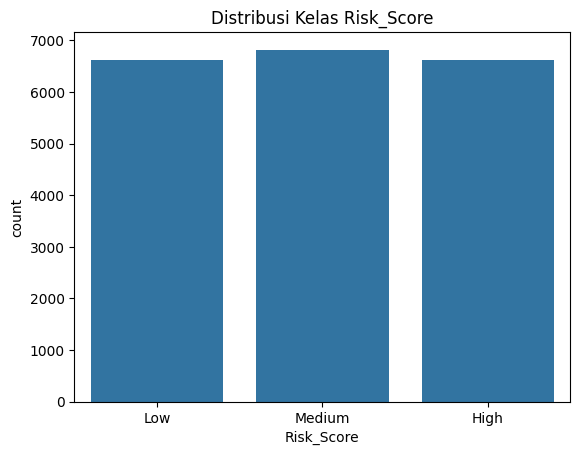

In [ ]:
# Melihat distribusi kelas target
print(anemia_df['Risk_Score'].value_counts())
print(anemia_df['Risk_Score'].value_counts(normalize=True) * 100)

sns.countplot(x='Risk_Score', data=anemia_df, order=['Low', 'Medium', 'High'])
plt.title('Distribusi Kelas Risk_Score')
plt.show()

**Insight Distribusi Target Risk Score**

- Kolom target `Risk_Score` terdiri dari tiga kategori:
  - Low
  - Medium
  - High

- Distribusi masing-masing kelas relatif seimbang, dengan proporsi sekitar 33% pada setiap kategori.

- Kondisi ini menunjukkan bahwa dataset tidak mengalami class imbalance yang signifikan.

In [ ]:
# Melihat missing values
missing_values = anemia_df.isnull().sum()
missing_values[missing_values > 0]

,0
Age,32
Height_cm,39
Weight_kg,39
Marital_Status,2
History_Anemia,47
Family_History_Anemia,54
Ever_Checked_Hb,31
Iron_Supplement,31
Currently_Pregnant,39
Regular_Menstruation,2


In [ ]:
missing_percentage = (anemia_df.isnull().sum() / len(anemia_df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
Menstruation_Days,0.308980
Menstrual_Blood_Volume,0.308980
Family_History_Anemia,0.269112
Stress_Level,0.234227
Water_Intake_Glasses,0.234227
History_Anemia,0.234227
Junk_Food_Frequency,0.194359
Gadget_Hours_Per_Day,0.194359
Height_cm,0.194359
Weight_kg,0.194359


**Insight Missing Values**

- Ditemukan missing values pada beberapa kolom dalam dataset, baik pada fitur numerik maupun kategorikal.

- Kolom dengan jumlah missing values tertinggi adalah:
  - `Menstruation_Days`
  - `Menstrual_Blood_Volume`
  - `Family_History_Anemia`
  
  Namun, secara persentase seluruh missing values masih tergolong sangat kecil (<1%) dibanding total data.

- Persentase missing values terbesar hanya sekitar 0,31%, sehingga kehilangan data masih tergolong rendah dan tidak terlalu memengaruhi keseluruhan distribusi dataset.

- Karena persentase missing values sangat kecil (<1%), penanganan dilakukan dengan menghapus baris yang mengandung missing values (dropna). Dengan total data 20.066 baris, kehilangan kurang dari 1% tidak berdampak signifikan terhadap distribusi

In [ ]:
# Melihat duplikasi data
print('Jumlah data duplikat:', anemia_df.duplicated().sum())

Jumlah data duplikat: 0


**Insight Data Duplikat**

- Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki data duplikat (`0 duplicated rows`).

In [ ]:
# Mengecek nilai unik pada kolom kategorial
categorical_cols = anemia_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\nKolom: {col}')
    print(anemia_df[col].unique())


Kolom: Marital_Status
['Belum Menikah' 'Menikah' 'Bercerai' nan]

Kolom: History_Anemia
['Ya' 'Tidak' nan]

Kolom: Family_History_Anemia
['Tidak' 'Ya' nan]

Kolom: Ever_Checked_Hb
['Ya' 'Tidak' nan]

Kolom: Iron_Supplement
['Tidak' 'Ya' nan]

Kolom: Currently_Pregnant
['Tidak' 'Ya' nan]

Kolom: Regular_Menstruation
['Tidak' 'Ya' nan]

Kolom: Menstrual_Blood_Volume
['Normal' 'Sedikit' 'Banyak' 'Sangat Banyak' nan]

Kolom: Meal_Frequency_Per_Day
['3x' 'Lebih dari 3x' '2x' '1x' nan]

Kolom: Eat_Breakfast
['Tidak' 'Ya' nan]

Kolom: Consume_RedMeat
['Sering (5-6x/minggu)' 'Tidak pernah' 'Jarang (1-2x/minggu)'
 'Setiap hari' 'Kadang (3-4x/minggu)']

Kolom: Consume_Liver
['Kadang (3-4x/minggu)' 'Tidak pernah' 'Jarang (1-2x/minggu)'
 'Sering (5-6x/minggu)' 'Setiap hari']

Kolom: Consume_Egg
['Sering (5-6x/minggu)' 'Setiap hari' 'Jarang (1-2x/minggu)'
 'Kadang (3-4x/minggu)' 'Tidak pernah']

Kolom: Consume_Fish
['Tidak pernah' 'Sering (5-6x/minggu)' 'Kadang (3-4x/minggu)'
 'Jarang (1-2x/minggu

**Insight Pemeriksaan Nilai Unik**
- Ditemukan missing values (NaN) pada 15 kolom kategorikal yang akan
  ditangani dengan imputasi modus.
- Kolom `Risk_Score` sebagai target label sudah bersih — 3 kelas:
  Low, Medium, High.
- Mayoritas kolom gejala dan konsumsi bersifat ordinal dengan skala
  frekuensi yang terurut, sehingga akan diencoding menggunakan
  OrdinalEncoder dengan urutan kategori yang ditentukan manual.
- Kolom `Meal_Frequency_Per_Day` akan dikonversi ke nilai numerik.
- Standarisasi teks (strip + lower) akan diterapkan untuk memastikan
  konsistensi penulisan sebelum encoding.

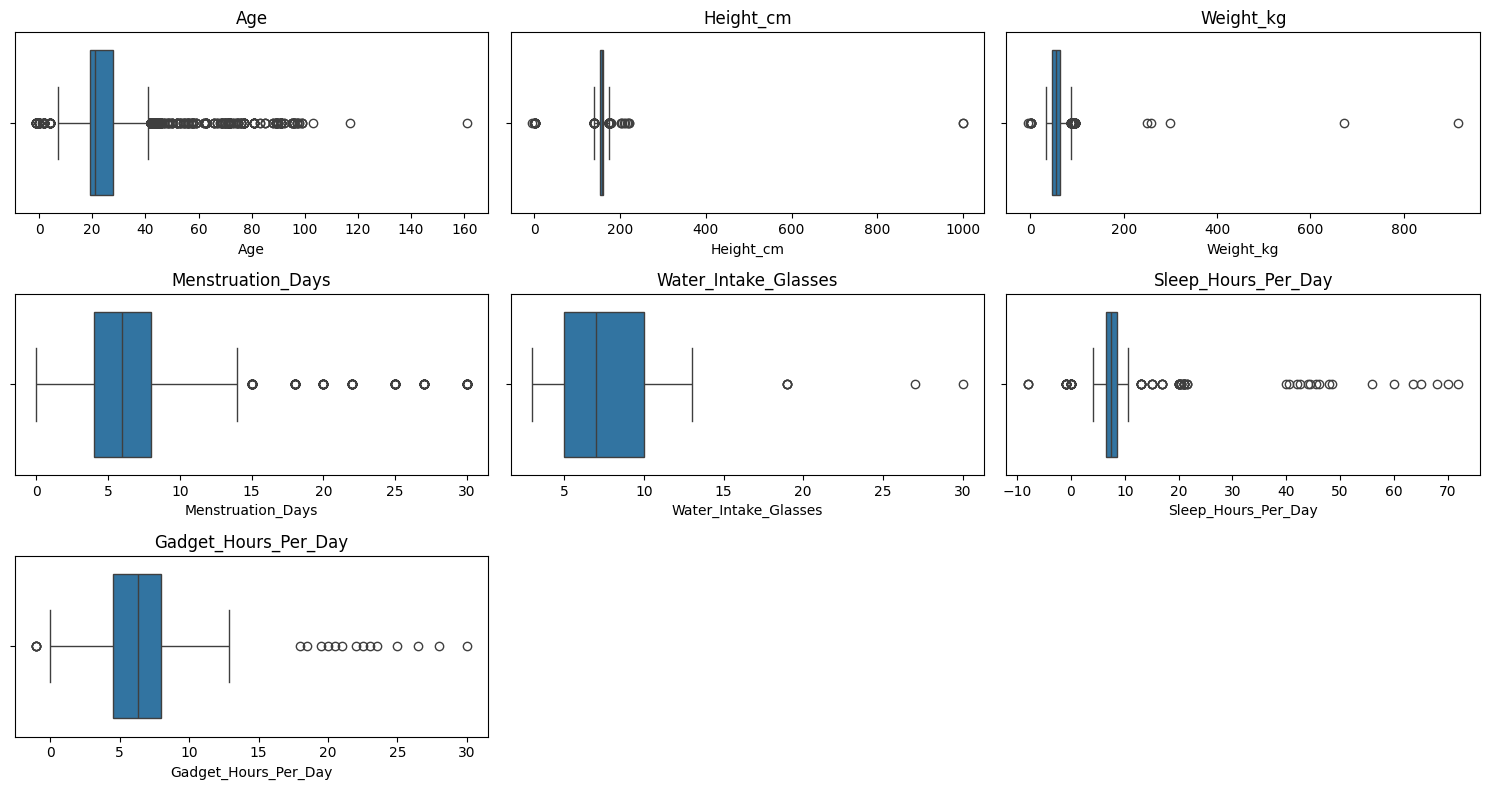

In [ ]:
# Deteksi nilai outlier
numerical_cols = anemia_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols)//3)+1, 3, i+1)
    sns.boxplot(x=anemia_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Insight Deteksi Outlier**

- Ditemukan beberapa outlier ekstrem pada kolom `Age`, `Height_cm`, dan `Weight_kg` yang kemungkinan besar berasal dari kesalahan input data karena nilainya tidak realistis secara biologis.

- Kolom `Height_cm` memiliki nilai minimum negatif, sedangkan `Sleep_Hours_Per_Day` juga memiliki nilai negatif yang secara logis tidak mungkin terjadi.

- Selain itu, kolom `Gadget_Hours_Per_Day` memiliki beberapa nilai melebihi 24 jam per hari yang mengindikasikan anomali data atau kesalahan input.

### Kesimpulan Assessing Data

Berdasarkan proses assessing data, ditemukan beberapa permasalahan pada dataset, yaitu:
- terdapat missing values pada beberapa fitur,
- terdapat outlier ekstrem dan nilai tidak realistis,
- tidak ditemukan data duplikat,
- distribusi target `Risk_Score` tergolong seimbang.

Secara keseluruhan, dataset cukup baik dan dapat dilanjutkan ke tahap cleaning data sebelum digunakan pada proses exploratory data analysis (EDA) dan modeling.

## Cleaning Data


Tahap cleaning data dilakukan untuk memperbaiki kualitas dataset sebelum digunakan pada tahap exploratory data analysis dan machine learning.

Proses cleaning meliputi:
- Menangani missing values
- Menstandarisasi data kategorikal
- Memperbaiki tipe data
- Menangani outlier

In [ ]:
# Membuat salinan dataset agar data asli tetap aman
df_clean = anemia_df.copy()

In [ ]:
before_rows = df_clean.shape[0]

# Hitung sebelum filter
dropped_age = ((df_clean['Age'] < 15) | (df_clean['Age'] > 49)).sum()
dropped_height = ((df_clean['Height_cm'] < 100) | (df_clean['Height_cm'] > 200)).sum()
dropped_weight = ((df_clean['Weight_kg'] < 20) | (df_clean['Weight_kg'] > 100)).sum()
dropped_sleep = ((df_clean['Sleep_Hours_Per_Day'] < 1) | (df_clean['Sleep_Hours_Per_Day'] > 24)).sum()
dropped_gadget = ((df_clean['Gadget_Hours_Per_Day'] < 0) | (df_clean['Gadget_Hours_Per_Day'] > 24)).sum()

print('=== Nilai Tidak Realistis yang Ditemukan ===')
print(f'Age tidak masuk target (< 15 atau > 49)          : {dropped_age}')
print(f'Height tidak realistis (< 100 atau > 200 cm)  : {dropped_height}')
print(f'Weight tidak realistis (< 20 atau > 100 kg)   : {dropped_weight}')
print(f'Sleep tidak realistis (< 1 atau > 24 jam)     : {dropped_sleep}')
print(f'Gadget tidak realistis (< 0 atau > 24 jam)    : {dropped_gadget}')

# Filter domain
df_clean = df_clean[
    (df_clean['Age'] >= 15) & (df_clean['Age'] <= 49) &
    (df_clean['Height_cm'] >= 100) & (df_clean['Height_cm'] <= 200) &
    (df_clean['Weight_kg'] >= 20) & (df_clean['Weight_kg'] <= 100) &
    (df_clean['Sleep_Hours_Per_Day'] >= 1) & (df_clean['Sleep_Hours_Per_Day'] <= 24) &
    (df_clean['Gadget_Hours_Per_Day'] >= 0) & (df_clean['Gadget_Hours_Per_Day'] <= 24)
]
after_domain = df_clean.shape[0]

# Cross check sleep + gadget
invalid_combined = df_clean[(df_clean['Sleep_Hours_Per_Day'] + df_clean['Gadget_Hours_Per_Day']) > 24]
dropped_sleep_gadget = len(invalid_combined)
df_clean = df_clean[(df_clean['Sleep_Hours_Per_Day'] + df_clean['Gadget_Hours_Per_Day']) <= 24]

# Cross check currently_pregnant vs menstruation_days
invalid_preg1 = df_clean[
    (df_clean['Currently_Pregnant'] == 'Ya') & (df_clean['Menstruation_Days'] > 0)
]
invalid_preg2 = df_clean[
    (df_clean['Currently_Pregnant'] == 'Tidak') & (df_clean['Menstruation_Days'] <= 0)
]

df_clean = df_clean[
    ~(
        ((df_clean['Currently_Pregnant'] == 'Ya') & (df_clean['Menstruation_Days'] > 0)) |
        ((df_clean['Currently_Pregnant'] == 'Tidak') & (df_clean['Menstruation_Days'] <= 0))
    )
]

after_rows = df_clean.shape[0]

print('\n=== Breakdown Data yang Dihapus ===')
print(f'Age tidak realistis                        : {dropped_age}')
print(f'Height tidak realistis                     : {dropped_height}')
print(f'Weight tidak realistis                     : {dropped_weight}')
print(f'Sleep tidak realistis                      : {dropped_sleep}')
print(f'Gadget tidak realistis                     : {dropped_gadget}')
print(f'Sleep + Gadget > 24 jam                    : {dropped_sleep_gadget}')
print(f'Hamil tapi mens_day > 0                    : {len(invalid_preg1)}')
print(f'Tidak hamil tapi mens_day <= 0             : {len(invalid_preg2)}')
print(f'─────────────────────────────────────────────')
print(f'Total dihapus                              : {before_rows - after_rows}')
print(f'Data tersisa                               : {after_rows}')

=== Nilai Tidak Realistis yang Ditemukan ===
Age tidak masuk target (< 15 atau > 49)          : 355
Height tidak realistis (< 100 atau > 200 cm)  : 23
Weight tidak realistis (< 20 atau > 100 kg)   : 14
Sleep tidak realistis (< 1 atau > 24 jam)     : 47
Gadget tidak realistis (< 0 atau > 24 jam)    : 9

=== Breakdown Data yang Dihapus ===
Age tidak realistis                        : 355
Height tidak realistis                     : 23
Weight tidak realistis                     : 14
Sleep tidak realistis                      : 47
Gadget tidak realistis                     : 9
Sleep + Gadget > 24 jam                    : 34
Hamil tapi mens_day > 0                    : 1777
Tidak hamil tapi mens_day <= 0             : 19
─────────────────────────────────────────────
Total dihapus                              : 2454
Data tersisa                               : 17612


**Insight Pemeriksaan dan Filtering Nilai Tidak Realistis**

Sebelum filtering, ditemukan beberapa nilai yang tidak realistis secara domain kesehatan:

- `Age` di luar rentang 15–49 tahun : 355 baris — rentang ini dipilih karena
  target pengguna Eye-Nemia adalah wanita usia produktif (15–49 tahun)
  sesuai dengan definisi WHO untuk wanita usia reproduktif. Data di luar
  rentang ini tidak relevan dengan konteks aplikasi.
- `Height_cm` di luar rentang 100–200 cm : 23 baris
- `Weight_kg` di luar rentang 20–100 kg  : 14 baris
- `Sleep_Hours_Per_Day` di luar rentang 1–24 jam : 47 baris
- `Gadget_Hours_Per_Day` di luar rentang 0–24 jam : 9 baris

Selain itu, ditemukan inkonsistensi antar kolom:
- 34 baris dengan kombinasi `Sleep_Hours_Per_Day + Gadget_Hours_Per_Day > 24 jam`
  — tidak mungkin terjadi dalam satu hari
- 1.777 baris dengan status hamil (`Currently_Pregnant = Ya`)
  namun `Menstruation_Days > 0` — tidak konsisten secara medis
- 19 baris dengan status tidak hamil (`Currently_Pregnant = Tidak`)
  namun `Menstruation_Days <= 0` — tidak konsisten secara medis

Seluruh baris tidak realistis dan inkonsisten ini dihapus dari dataset.

Hasil filtering:
- Total data dihapus : 2.454 baris
- Data tersisa       : 17.612 baris (~87,7% dari data awal)

Meskipun jumlah yang dihapus cukup signifikan, hal ini diperlukan untuk
memastikan kualitas data yang digunakan dalam pemodelan bebas dari
inkonsistensi logis dan nilai yang tidak masuk akal secara domain kesehatan.

In [ ]:
drop_cols = [
    'Marital_Status',
    'History_Anemia',
    'Family_History_Anemia',
    'Ever_Checked_Hb',
    'Iron_Supplement',
    'Sleep_Hours_Per_Day',
    'Physical_Activity',
    'Gadget_Hours_Per_Day',
    'Stress_Level',
    'Busyness_Level'
]

df_clean = df_clean.drop(columns=drop_cols)
print(f'Shape setelah drop kolom: {df_clean.shape}')
print(f'Kolom tersisa: {df_clean.columns.tolist()}')

Shape setelah drop kolom: (17612, 32)
Kolom tersisa: ['Age', 'Height_cm', 'Weight_kg', 'Currently_Pregnant', 'Regular_Menstruation', 'Menstruation_Days', 'Menstrual_Blood_Volume', 'Meal_Frequency_Per_Day', 'Eat_Breakfast', 'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg', 'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts', 'Consume_FruitVitC', 'Tea_After_Meal', 'Coffee_After_Meal', 'Junk_Food_Frequency', 'Water_Intake_Glasses', 'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_Headache', 'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_PaleSkin', 'Symptom_ColdExtremities', 'Symptom_Palpitation', 'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness', 'Risk_Score']


### Menangani Missing Values

Strategi penanganan missing values disesuaikan dengan tipe data:
- Fitur numerik → imputasi median/mean
- Fitur kategorikal → imputasi modus

In [ ]:
# Cek missing Currently_Pregnant
print('Missing Currently_Pregnant:', df_clean['Currently_Pregnant'].isna().sum())

# Domain-based imputation Currently_Pregnant
df_clean.loc[
    df_clean['Currently_Pregnant'].isna() & (df_clean['Menstruation_Days'] == 0),
    'Currently_Pregnant'
] = 'Ya'

df_clean.loc[
    df_clean['Currently_Pregnant'].isna() & (df_clean['Menstruation_Days'] > 0),
    'Currently_Pregnant'
] = 'Tidak'

print('Missing Currently_Pregnant setelah imputation:', df_clean['Currently_Pregnant'].isna().sum())

# 3. Drop sisa missing values kolom lain
missing_before = df_clean.isnull().sum().sum()
print(f'Jumlah missing values sebelum drop : {missing_before}')

# Cek kolom mana yang masih ada missing values
print('=== Kolom dengan Missing Values ===')
missing_per_col = df_clean.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0].sort_values(ascending=False)
print(missing_per_col)
print(f'\nTotal baris terdampak: {df_clean[df_clean.isnull().any(axis=1)].shape[0]}')

df_clean = df_clean.dropna()

missing_after = df_clean.isnull().sum().sum()
print(f'Jumlah missing values sesudah drop : {missing_after}')
print(f'Jumlah baris tersisa : {df_clean.shape[0]}')

Missing Currently_Pregnant: 38
Missing Currently_Pregnant setelah imputation: 0
Jumlah missing values sebelum drop : 215
=== Kolom dengan Missing Values ===
Menstruation_Days         60
Menstrual_Blood_Volume    53
Water_Intake_Glasses      41
Junk_Food_Frequency       35
Meal_Frequency_Per_Day    21
Consume_GreenVeg           2
Eat_Breakfast              2
Regular_Menstruation       1
dtype: int64

Total baris terdampak: 214
Jumlah missing values sesudah drop : 0
Jumlah baris tersisa : 17398


**Insight Penanganan Missing Values**

Penanganan missing values dilakukan dengan dua pendekatan:

1. Domain-based Imputation (Currently_Pregnant)
- Ditemukan 38 missing values pada kolom `Currently_Pregnant`
- Ditangani menggunakan logika domain kesehatan:
  - Jika `Menstruation_Days == 0` → diisi `Ya` (kemungkinan sedang hamil)
  - Jika `Menstruation_Days > 0` → diisi `Tidak`
- Setelah imputation, missing values `Currently_Pregnant` tersisa: 0
- Pendekatan ini lebih baik dari sekadar drop karena tidak menghilangkan
  data dan keputusan imputasi didasarkan pada logika medis yang valid.

2. Drop (Kolom Lainnya)
Setelah imputation Currently_Pregnant, masih terdapat 215 missing values
pada 8 kolom berikut:

- `Menstruation_Days`     : 60 baris
- `Menstrual_Blood_Volume`: 53 baris
- `Water_Intake_Glasses`  : 41 baris
- `Junk_Food_Frequency`   : 35 baris
- `Meal_Frequency_Per_Day`: 21 baris
- `Consume_GreenVeg`      : 2 baris
- `Eat_Breakfast`         : 2 baris
- `Regular_Menstruation`  : 1 baris

Total baris terdampak sebanyak 214 baris (bukan 215 karena ada baris
yang memiliki missing values di lebih dari satu kolom sekaligus).
Karena jumlahnya kecil (<1,2% dari total data), baris-baris ini
dihapus menggunakan dropna tanpa berdampak signifikan terhadap
distribusi dan kualitas dataset.

- Jumlah baris tersisa: 17.398 baris

### Menangani Outlier

Outlier ditangani menggunakan metode IQR (Interquartile Range).

In [ ]:
before_capping = df_clean.shape[0]

# Kolom numerik yang akan dicapping
num_cols = df_clean.select_dtypes(include=['float64']).columns.tolist()

# Age tidak perlu di-capping, sudah divalidasi di filtering
if 'Age' in num_cols:
    num_cols.remove('Age')

print("=== Nilai sebelum IQR Capping ===")
print(df_clean[num_cols].describe())

# Menyimpan statistik outlier
outlier_counts = {}
outlier_rows_index = set()

# IQR Capping (Winsorizing)
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 1. Identifikasi dan hitung outlier sebelum capping
    outliers_condition = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_counts[col] = outliers_condition.sum()

    # Simpan index baris yang terkena outlier
    outlier_rows_index.update(df_clean[outliers_condition].index)

    # 3. Proses capping
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# --- TAMPILKAN HASIL OUTLIER ---
print("\n=== Jumlah Outlier yang Ditemukan (Sebelum di-Cap) ===")
for col, count in outlier_counts.items():
    persentase = (count / before_capping) * 100
    print(f"- {col}: {count} baris ({persentase:.2f}%)")

total_outlier_rows = len(outlier_rows_index)
persentase_total = (total_outlier_rows / before_capping) * 100
print(f"\n>> TOTAL BARIS dengan setidaknya 1 outlier: {total_outlier_rows} baris ({persentase_total:.2f}%)")

print("\n=== Nilai setelah IQR Capping ===")
print(df_clean[num_cols].describe())

print(f'\nJumlah baris setelah capping: {df_clean.shape[0]} (Tidak ada baris yang dihapus, hanya nilainya yang diubah)')

=== Nilai sebelum IQR Capping ===
          Height_cm     Weight_kg  Menstruation_Days  Water_Intake_Glasses
count  17398.000000  17398.000000       17398.000000          17398.000000
mean     156.797930     55.595993           6.152719              7.486665
std        6.039836     11.540891           2.475902              2.897478
min      140.000000     33.000000           0.000000              3.000000
25%      152.700000     47.000000           4.000000              5.000000
50%      156.825000     55.000000           6.000000              7.000000
75%      161.000000     63.350000           8.000000             10.000000
max      179.000000     96.620000          30.000000             30.000000

=== Jumlah Outlier yang Ditemukan (Sebelum di-Cap) ===
- Height_cm: 81 baris (0.47%)
- Weight_kg: 105 baris (0.60%)
- Menstruation_Days: 129 baris (0.74%)
- Water_Intake_Glasses: 5 baris (0.03%)

>> TOTAL BARIS dengan setidaknya 1 outlier: 313 baris (1.80%)

=== Nilai setelah IQR Capping =

**Insight Penanganan Outlier (IQR Capping)**

Outlier ditangani menggunakan metode IQR Capping (Winsorizing)
pada seluruh kolom numerik bertipe float64, yaitu Height_cm,
Weight_kg, Menstruation_Days, dan Water_Intake_Glasses.

Perbandingan sebelum dan sesudah capping:

- `Height_cm`: nilai maksimum turun dari 179.00 → 173.450 cm,
  memastikan tidak ada nilai tinggi badan yang tidak realistis.
- `Weight_kg`: nilai maksimum turun dari 96.62 → 87.875 kg,
  sesuai rentang berat badan yang wajar.
- `Menstruation_Days`: nilai maksimum turun dari 30.0 → 14.0 hari,
  lebih sesuai dengan durasi menstruasi yang dapat diterima secara medis.
- `Water_Intake_Glasses`: nilai maksimum turun dari 30.0 → 17.5 gelas,
  meskipun masih sedikit di atas normal namun jauh lebih representatif
  dibanding nilai ekstrem sebelumnya.

Jumlah baris tidak berkurang setelah capping (tetap 17.398 baris)
karena metode ini mengganti nilai ekstrem dengan nilai batas,
bukan menghapus baris.

### Memperbaiki tipe data
Mengubah tipe data `Age` yang semula bertipe data float menjadi tipe data integer

In [ ]:
# Cek kolom numerik yang aman diubah ke integer

check_cols = [
    'Age',
    'Menstruation_Days',
    'Water_Intake_Glasses',
]

for col in check_cols:
    decimal_count = (df_clean[col] % 1 != 0).sum()
    print(f'{col} -> Jumlah nilai desimal: {decimal_count}')

Age -> Jumlah nilai desimal: 0
Menstruation_Days -> Jumlah nilai desimal: 0
Water_Intake_Glasses -> Jumlah nilai desimal: 5


In [ ]:
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Menstruation_Days'] = df_clean['Menstruation_Days'].astype(int)
df_clean['Water_Intake_Glasses'] = df_clean['Water_Intake_Glasses'].astype(int)

int_cols = ['Age', 'Menstruation_Days', 'Water_Intake_Glasses']
print(df_clean[int_cols].dtypes)

Age                     int64
Menstruation_Days       int64
Water_Intake_Glasses    int64
dtype: object


**Insight Perbaikan Tipe Data**

Berdasarkan pemeriksaan tipe data numerik, beberapa fitur seperti `Age`, `Menstruation_Days`, dan `Water_Intake_Glasses` tidak memiliki nilai desimal sehingga diubah dari tipe `float` menjadi `integer`.

### Verifikasi hasil cleaning data

In [ ]:
print(df_clean.shape)

(17398, 32)


In [ ]:
print(df_clean.isnull().sum().sum())

0


In [ ]:
print(df_clean.duplicated().sum())

0


In [ ]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 17398 entries, 1 to 20056
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        17398 non-null  int64  
 1   Height_cm                  17398 non-null  float64
 2   Weight_kg                  17398 non-null  float64
 3   Currently_Pregnant         17398 non-null  object 
 4   Regular_Menstruation       17398 non-null  object 
 5   Menstruation_Days          17398 non-null  int64  
 6   Menstrual_Blood_Volume     17398 non-null  object 
 7   Meal_Frequency_Per_Day     17398 non-null  object 
 8   Eat_Breakfast              17398 non-null  object 
 9   Consume_RedMeat            17398 non-null  object 
 10  Consume_Liver              17398 non-null  object 
 11  Consume_Egg                17398 non-null  object 
 12  Consume_Fish               17398 non-null  object 
 13  Consume_GreenVeg           17398 non-null  object 


**Insight Verifikasi Akhir**

Dataset telah melalui seluruh proses cleaning dan siap digunakan
untuk tahap Exploratory Data Analysis (EDA) dan modeling.
- Tidak ada missing values
- Tidak ada data duplikat  
- Tipe data sudah sesuai
- Nilai tidak realistis sudah dihapus
- Outlier sudah ditangani dengan IQR Capping

In [ ]:
df_clean.to_csv("eye_nemia_clean.csv", index=False)

print("Dataset clean berhasil disimpan.")

Dataset clean berhasil disimpan.


# Data Encoding

Tahap data processing dilakukan untuk mempersiapkan dataset
hasil cleaning agar dapat digunakan oleh algoritma machine learning.

Proses ini meliputi:
- Binary Encoding
- Ordinal Encoding  
- Label Encoding (kolom target)

### Binary encoding


In [ ]:
binary_cols = ['Regular_Menstruation', 'Eat_Breakfast', 'Currently_Pregnant']

binary_map = {'Ya': 1, 'Tidak': 0}

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

# Verifikasi
print(df_clean[binary_cols].head(10))
print()
print(df_clean[binary_cols].value_counts())

    Regular_Menstruation  Eat_Breakfast  Currently_Pregnant
1                      1              0                   0
2                      1              0                   0
3                      0              1                   0
4                      0              0                   0
5                      1              1                   0
6                      1              0                   0
7                      1              1                   0
8                      0              0                   0
10                     1              1                   0
11                     1              1                   0

Regular_Menstruation  Eat_Breakfast  Currently_Pregnant
1                     1              0                     6210
                      0              0                     5200
0                     1              0                     3295
                      0              0                     2690
                      1    

**Insight Binary Encoding**

Kolom `Regular_Menstruation` dan `Eat_Breakfast` diencoding
menggunakan binary encoding karena hanya memiliki dua nilai
kategori (Ya/Tidak).

Nilai 'Ya' dikonversi menjadi 1 dan 'Tidak' menjadi 0
menggunakan `.map()`.

Hasil encoding menunjukkan:
- Mayoritas pengguna memiliki menstruasi teratur (Regular_Menstruation = 1)
  yaitu sekitar 10.705 dari total data.
- Mayoritas pengguna sarapan (Eat_Breakfast = 1)
  yaitu sekitar 12.858 dari total data.
- Tidak ditemukan NaN setelah proses mapping,
  artinya seluruh nilai berhasil dikonversi dengan sempurna.

### Ordinal encoding

In [ ]:
# Definisikan urutan kategori per skala
skala_konsumsi = ['Tidak pernah', 'Jarang (1-2x/minggu)',
                  'Kadang (3-4x/minggu)', 'Sering (5-6x/minggu)',
                  'Setiap hari']

skala_gejala = ['Tidak pernah', 'Jarang',
                'Kadang-kadang', 'Sering', 'Selalu']

skala_junkfood = ['Tidak pernah', 'Jarang', 'Kadang',
                  'Sering', 'Sangat sering']

skala_menstruasi = ['Sedikit', 'Normal', 'Banyak', 'Sangat Banyak']

# Definisikan kolom per skala
cols_konsumsi = [
    'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg',
    'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts',
    'Consume_FruitVitC', 'Tea_After_Meal', 'Coffee_After_Meal'
]

cols_gejala = [
    'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_Headache',
    'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_PaleSkin',
    'Symptom_ColdExtremities', 'Symptom_Palpitation',
    'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness'
]

cols_junkfood = ['Junk_Food_Frequency']
cols_menstruasi = ['Menstrual_Blood_Volume']

# Terapkan OrdinalEncoder per kelompok
encoder_konsumsi = OrdinalEncoder(categories=[skala_konsumsi] * len(cols_konsumsi))
df_clean[cols_konsumsi] = encoder_konsumsi.fit_transform(df_clean[cols_konsumsi])

encoder_gejala = OrdinalEncoder(categories=[skala_gejala] * len(cols_gejala))
df_clean[cols_gejala] = encoder_gejala.fit_transform(df_clean[cols_gejala])

encoder_junkfood = OrdinalEncoder(categories=[skala_junkfood])
df_clean[cols_junkfood] = encoder_junkfood.fit_transform(df_clean[cols_junkfood])

encoder_menstruasi = OrdinalEncoder(categories=[skala_menstruasi])
df_clean[cols_menstruasi] = encoder_menstruasi.fit_transform(df_clean[cols_menstruasi])

ordinal_cols = cols_konsumsi + cols_gejala + cols_junkfood + cols_menstruasi
df_clean[ordinal_cols] = df_clean[ordinal_cols].astype(int)

meal_map = {'1x': 1, '2x': 2, '3x': 3, 'Lebih dari 3x': 4}
df_clean['Meal_Frequency_Per_Day'] = df_clean['Meal_Frequency_Per_Day'].map(meal_map)

# Verifikasi
print(df_clean[ordinal_cols + ['Meal_Frequency_Per_Day']].head())
print()
print('Cek NaN setelah encoding:')
print(df_clean[ordinal_cols + ['Meal_Frequency_Per_Day']].isnull().sum().sum())
print()
print('Tipe data setelah fix:')
print(df_clean[ordinal_cols + ['Meal_Frequency_Per_Day']].dtypes.unique())

   Consume_RedMeat  Consume_Liver  Consume_Egg  Consume_Fish  \
1                0              0            4             3   
2                1              1            1             3   
3                1              1            3             2   
4                0              1            2             1   
5                0              0            1             2   

   Consume_GreenVeg  Consume_Nuts  Consume_FruitVitC  Tea_After_Meal  \
1                 2             1                  2               3   
2                 2             2                  2               0   
3                 2             4                  1               0   
4                 4             2                  4               0   
5                 3             0                  2               0   

   Coffee_After_Meal  Symptom_Fatigue  ...  Symptom_LowFocus  \
1                  2                0  ...                 3   
2                  0                0  ...            

**Insight Ordinal Encoding**

Sebanyak 22 kolom kategorikal yang bersifat ordinal diencoding
menggunakan OrdinalEncoder dengan urutan kategori yang ditentukan secara manual sesuai konteks medis dan logika frekuensi.

Encoding dibagi menjadi 4 kelompok skala:

1. Skala konsumsi makanan (9 kolom: Consume_RedMeat, Consume_Liver,
   Consume_Egg, Consume_Fish, Consume_GreenVeg, Consume_Nuts,
   Consume_FruitVitC, Tea_After_Meal, Coffee_After_Meal):
   Tidak pernah (0) → Jarang (1) → Kadang (2) → Sering (3) → Setiap hari (4)

2. Skala gejala fisik (11 kolom: Symptom_Fatigue, Symptom_Dizziness,
   Symptom_Headache, Symptom_Breathlessness, Symptom_LowFocus,
   Symptom_PaleSkin, Symptom_ColdExtremities, Symptom_Palpitation,
   Symptom_HairLoss, Symptom_Weakness, Symptom_DaytimeSleepiness):
   Tidak pernah (0) → Jarang (1) → Kadang-kadang (2) → Sering (3) → Selalu (4)

3. Skala junk food (1 kolom: Junk_Food_Frequency):
   Tidak pernah (0) → Jarang (1) → Kadang (2) → Sering (3) → Sangat sering (4)

4. Skala volume menstruasi (1 kolom: Menstrual_Blood_Volume):
   Sedikit (0) → Normal (1) → Banyak (2) → Sangat Banyak (3)

Pendekatan manual dipilih dibanding LabelEncoder otomatis karena
urutan kategori yang salah dapat menyebabkan model salah
menginterpretasikan tingkat risiko, misalnya, "Selalu" harus
bernilai lebih tinggi dari "Jarang" agar model memahami bahwa
gejala yang lebih sering = risiko lebih tinggi.

Hasil verifikasi menunjukkan tidak ada NaN setelah proses encoding,
artinya seluruh nilai berhasil dikonversi dengan baik

### Label Encoding

In [ ]:
# Label Encoding kolom target Risk_Score
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}

df_clean['Risk_Score'] = df_clean['Risk_Score'].map(risk_map)

# Verifikasi
print(df_clean['Risk_Score'].value_counts().sort_index())
print()
print('Cek NaN setelah encoding:')
print(df_clean['Risk_Score'].isnull().sum())

Risk_Score
0    5755
1    5862
2    5781
Name: count, dtype: int64

Cek NaN setelah encoding:
0


**Insight Label Encoding Risk_Score**

Kolom target `Risk_Score` diencoding secara manual menggunakan
`.map()` dengan urutan:
- Low   → 0
- Medium → 1  
- High  → 2

Urutan ini mencerminkan tingkat keparahan risiko anemia secara
logis dari rendah ke tinggi.

### Verifikasi akhir data processing

In [ ]:
print(f'Shape dataset       : {df_clean.shape}')
print(f'Tipe data kolom     :')
print(df_clean.dtypes)
print()
print(f'Cek NaN             : {df_clean.isnull().sum().sum()}')
print()
print('5 baris pertama:')
df_clean.head()

Shape dataset       : (17398, 32)
Tipe data kolom     :
Age                            int64
Height_cm                    float64
Weight_kg                    float64
Currently_Pregnant             int64
Regular_Menstruation           int64
Menstruation_Days              int64
Menstrual_Blood_Volume         int64
Meal_Frequency_Per_Day         int64
Eat_Breakfast                  int64
Consume_RedMeat                int64
Consume_Liver                  int64
Consume_Egg                    int64
Consume_Fish                   int64
Consume_GreenVeg               int64
Consume_Nuts                   int64
Consume_FruitVitC              int64
Tea_After_Meal                 int64
Coffee_After_Meal              int64
Junk_Food_Frequency            int64
Water_Intake_Glasses           int64
Symptom_Fatigue                int64
Symptom_Dizziness              int64
Symptom_Headache               int64
Symptom_Breathlessness         int64
Symptom_LowFocus               int64
Symptom_PaleSkin   

,Age,Height_cm,Weight_kg,Currently_Pregnant,Regular_Menstruation,Menstruation_Days,Menstrual_Blood_Volume,Meal_Frequency_Per_Day,Eat_Breakfast,Consume_RedMeat,...,Symptom_Headache,Symptom_Breathlessness,Symptom_LowFocus,Symptom_PaleSkin,Symptom_ColdExtremities,Symptom_Palpitation,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Risk_Score
1,22,173.45,87.875,0,1,5,0,4,0,0,...,1,0,3,0,1,0,1,1,2,0
2,19,173.45,87.875,0,1,9,2,3,0,1,...,1,1,1,0,1,0,0,1,0,1
3,36,173.45,87.875,0,0,8,2,2,1,1,...,2,1,2,0,2,0,1,1,4,2
4,24,173.45,86.000,0,0,7,1,3,0,0,...,0,0,3,0,0,0,0,1,0,0
5,33,173.45,87.875,0,1,7,3,3,1,0,...,1,2,0,0,1,0,1,0,2,1


In [ ]:
# Export dataset final setelah encoding
df_clean.to_csv('processed_eyenemia_dataset.csv', index=False)
print('Dataset processed berhasil disimpan!')
print(f'Shape final: {df_clean.shape}')

Dataset processed berhasil disimpan!
Shape final: (17398, 32)


# Feature Engineering

Tahap feature engineering dilakukan untuk membuat fitur baru yang lebih representatif terhadap pola risiko anemia. Fitur turunan dibuat berdasarkan kombinasi gejala, pola makan, dan kondisi menstruasi agar model dapat memahami hubungan antar variabel dengan lebih baik.

## Membuat salinan
Dataset disalin terlebih dahulu agar proses feature engineering tidak mengubah dataset asli hasil preprocessing.

In [ ]:
# Membuat salinan dataset hasil preprocessing

df_fe = df_clean.copy()
print(f'Shape awal: {df_fe.shape}')

Shape awal: (17398, 32)


## Membuat fitur BMI
Fitur BMI dibuat dari kombinasi `Height_cm` dan `Weight_kg` menggunakan
rumus standar WHO.

In [ ]:
# BMI = berat badan (kg) / tinggi badan (m)²
df_fe['BMI'] = df_fe['Weight_kg'] / ((df_fe['Height_cm'] / 100) ** 2)
df_fe['BMI'] = df_fe['BMI'].round(2)

print('Statistik BMI:')
print(df_fe['BMI'].describe().round(2))

Statistik BMI:
count    17398.00
mean        22.65
std          4.71
min         11.68
25%         19.16
50%         22.47
75%         25.75
max         44.67
Name: BMI, dtype: float64


**Insight BMI:**

Fitur `BMI` dibuat dari kombinasi `Weight_kg` dan `Height_cm`
menggunakan rumus standar WHO: berat badan (kg) dibagi kuadrat
tinggi badan (m). Fitur ini lebih bermakna secara klinis
dibandingkan menggunakan tinggi dan berat badan secara terpisah.
Berdasarkan hasil statistik deskriptif:

- Rata-rata BMI pengguna sebesar 22.65 yang termasuk dalam kategori
  normal (18.5–24.9), menunjukkan mayoritas pengguna memiliki
  status gizi yang sehat.
- Nilai minimum 11.68 mengindikasikan ada pengguna dengan kondisi
  severely underweight yang berisiko tinggi terhadap anemia
  berdasarkan referensi jurnal yang digunakan.
- Nilai maksimum 44.46 menunjukkan ada pengguna dalam kategori
  obese — yang berdasarkan jurnal justru lebih terlindungi
  dari anemia dibandingkan underweight.
- Median 22.47 yang sangat dekat dengan mean 22.66 menunjukkan
  distribusi BMI yang cukup simetris di sekitar nilai normal.
- Rentang IQR (Q1=19.18 hingga Q3=25.76) mencakup sebagian besar
  pengguna di kategori normal hingga sedikit overweight.

Berdasarkan referensi jurnal proyek ini, wanita underweight
(BMI < 18.5) terbukti 1.23x lebih berisiko mengalami anemia,
sementara wanita overweight justru lebih terlindungi.

In [ ]:
# Binning BMI
bins = [0, 18.5, 25, 30, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_fe['BMI_Category'] = pd.cut(df_fe['BMI'], bins=bins, labels=labels)

# Encoding BMI_Category langsung
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_fe['BMI_Category'] = pd.Categorical(df_fe['BMI_Category'], categories=bmi_order, ordered=True)
df_fe['BMI_Category'] = df_fe['BMI_Category'].cat.codes

print(df_fe['BMI_Category'].value_counts())

BMI_Category
1    8578
2    4101
0    3568
3    1151
Name: count, dtype: int64


**Insight BMI Category:**

Kolom `BMI_Category` dibuat dengan membagi nilai BMI ke dalam 4 kategori
berdasarkan standar WHO:

- Normal (18.5–24.9) : 9.474 orang (49,3%) — mayoritas pengguna
- Overweight (25–29.9) : 4.510 orang (23,5%)
- Underweight (< 18.5) : 3.921 orang (20,4%)
- Obese (≥ 30)         : 1.273 orang (6,6%)

Binning ini dilakukan karena hubungan antara BMI dan risiko anemia
bersifat non-linear — kategori underweight memiliki risiko anemia lebih
tinggi karena kemungkinan kekurangan nutrisi, sementara kategori obese
juga berisiko akibat inflamasi kronis yang dapat mengganggu penyerapan
zat besi. Dengan binning, model dapat menangkap pola klinis ini lebih baik
dibandingkan menggunakan nilai BMI mentah.

## Membuat fitur iron rich food score
Fitur ini merepresentasikan seberapa sering pengguna mengonsumsi makanan kaya zat besi. Skor lebih tinggi berarti asupan zat besi lebih baik.

In [ ]:
# Bobot kandungan zat besi per 100g (sumber: nutritionvalue.org)
iron_weights = {
    'Consume_Liver': 6.1,
    'Consume_RedMeat': 2.4,
    'Consume_Egg': 2.4,
    'Consume_Fish': 1.0
}

df_fe['Iron_Rich_Food_Score'] = (
    df_fe['Consume_Liver'] * iron_weights['Consume_Liver'] +
    df_fe['Consume_RedMeat'] * iron_weights['Consume_RedMeat'] +
    df_fe['Consume_Egg'] * iron_weights['Consume_Egg'] +
    df_fe['Consume_Fish'] * iron_weights['Consume_Fish']
)

print('Statistik Iron_Rich_Food_Score:')
print(df_fe['Iron_Rich_Food_Score'].describe().round(2))

Statistik Iron_Rich_Food_Score:
count    17398.00
mean        17.79
std          7.77
min          0.00
25%         11.90
50%         16.70
75%         22.50
max         46.60
Name: Iron_Rich_Food_Score, dtype: float64


**Insight Iron Rich Food Score:**

Fitur `Iron_Rich_Food_Score` dibuat dari akumulasi 4 sumber makanan
utama kaya zat besi hewani (heme iron) dengan pembobotan berdasarkan
kandungan zat besi per 100g (sumber: nutritionvalue.org):

- Hati sapi (`Consume_Liver`)    : bobot 6.1 mg/100g
- Daging merah (`Consume_RedMeat`): bobot 2.4 mg/100g
- Telur (`Consume_Egg`)          : bobot 2.4 mg/100g
- Ikan/tuna (`Consume_Fish`)     : bobot 1.0 mg/100g

Zat besi hewani (heme iron) dipilih karena penyerapannya oleh tubuh
jauh lebih efektif dibanding zat besi nabati (non-heme), sehingga
lebih representatif dalam menggambarkan asupan zat besi yang
fungsional bagi tubuh.

Berdasarkan hasil statistik deskriptif:
- Rata-rata skor sebesar **17.79** dari maksimum 46.6
- Nilai minimum 0.0 menunjukkan ada pengguna yang sama sekali
  tidak mengonsumsi sumber zat besi hewani
- Semakin rendah `Iron_Rich_Food_Score`, semakin tinggi risiko
  kekurangan zat besi yang dapat memicu anemia

## Membuat fitur iron inhibitor score
Fitur ini merepresentasikan kebiasaan yang menghambat penyerapan zat besi, yaitu konsumsi teh dan kopi setelah makan.

In [ ]:
# Teh dan kopi mengandung tanin/kafein yang menghambat absorpsi zat besi
inhibitor_cols = ['Tea_After_Meal', 'Coffee_After_Meal']

df_fe['Iron_Inhibitor_Score'] = df_fe[inhibitor_cols].sum(axis=1)

print('Statistik Iron_Inhibitor_Score:')
print(df_fe['Iron_Inhibitor_Score'].describe().round(2))

Statistik Iron_Inhibitor_Score:
count    17398.00
mean         0.91
std          1.38
min          0.00
25%          0.00
50%          0.00
75%          2.00
max          8.00
Name: Iron_Inhibitor_Score, dtype: float64


**Insight Iron Inhibitor Score:**

Fitur `Iron_Inhibitor_Score` dibuat dari akumulasi kebiasaan konsumsi
teh dan kopi setelah makan yang masing-masing bernilai 0–4, sehingga
rentang teoretisnya adalah 0–8.
Berdasarkan hasil statistik deskriptif:

- Rata-rata skor hanya 0.90 dari maksimum 8 menunjukkan bahwa
  sebagian besar pengguna tidak terlalu sering mengonsumsi teh
  maupun kopi setelah makan.
- Median 0.00 yang jauh lebih rendah dari mean 0.90 mengindikasikan
  distribusi yang sangat right-skewed — mayoritas pengguna memiliki
  skor 0, namun ada sebagian kecil yang skornya cukup tinggi
  sehingga menarik mean ke atas.
- Nilai Q1 dan median sama-sama 0.00 mengonfirmasi bahwa lebih dari
  50% pengguna tidak memiliki kebiasaan ini sama sekali.
- Nilai maksimum 8.00 (mencapai batas teoretis) menunjukkan ada
  pengguna yang sangat sering mengonsumsi keduanya setiap hari.
- Standar deviasi 1.37 yang lebih besar dari mean 0.90 mencerminkan
  variasi yang tinggi — sebagian besar pengguna skornya rendah,
  namun outlier di skor tinggi cukup memengaruhi distribusi.

Meskipun skor rata-rata rendah, fitur ini tetap penting karena
pengguna dengan skor tinggi memiliki risiko hambatan penyerapan
zat besi yang signifikan, terutama jika dikombinasikan dengan
`Iron_Rich_Food_Score` yang juga rendah.

## Membuat fitur menstruation risk
Fitur ini merepresentasikan risiko anemia dari kondisi menstruasi, dengan mempertimbangkan durasi dan volume darah yang dikeluarkan.

In [ ]:
# Skor risiko: gabungan durasi (bobot 0.5) + volume darah (bobot 0.5)
df_fe['Menstruation_Risk'] = (df_fe['Menstruation_Days'] * 0.5) + \
                              (df_fe['Menstrual_Blood_Volume'] / 3 * 0.5)

df_fe['Menstruation_Risk'] = df_fe['Menstruation_Risk'].round(4)

print('Statistik Menstruation_Risk:')
print(df_fe['Menstruation_Risk'].describe().round(4))

Statistik Menstruation_Risk:
count    17398.0000
mean         3.2603
std          1.0742
min          0.1667
25%          2.3333
50%          3.1667
75%          4.1667
max          7.5000
Name: Menstruation_Risk, dtype: float64


**Insight Menstruation Risk:**

Fitur `Menstruation_Risk` dibuat dengan menggabungkan dua indikator
kehilangan darah — durasi menstruasi (`Menstruation_Days`) dan volume
darah (`Menstrual_Blood_Volume`) — masing-masing dengan bobot 0.5,
sehingga rentang nilainya adalah 0.0–1.0.
Berdasarkan hasil statistik deskriptif:

- Rata-rata skor 0.4305 menunjukkan bahwa secara umum pengguna
  berada di tingkat risiko menstruasi sedang, tidak terlalu rendah
  maupun terlalu tinggi.
- Nilai minimum 0.0000 mengindikasikan ada pengguna dengan durasi
  sangat pendek sekaligus volume darah sangat sedikit, sehingga
  risiko kehilangan zat besi dari menstruasi sangat minimal.
- Nilai maksimum 1.0000 menunjukkan ada pengguna yang mencapai
  skor risiko tertinggi, yaitu durasi menstruasi panjang sekaligus
  volume darah sangat banyak.
- Median 0.4167 yang sangat dekat dengan mean 0.4305 menunjukkan
  distribusi yang cukup simetris tanpa skewness signifikan.
- Rentang IQR (Q1=0.3095 hingga Q3=0.4881) yang relatif sempit
  menunjukkan mayoritas pengguna terkonsentrasi di kisaran risiko
  menstruasi sedang.

Fitur ini penting karena kehilangan darah akibat menstruasi
merupakan salah satu penyebab utama anemia defisiensi besi pada
wanita usia produktif. Dengan menggabungkan durasi dan volume
dalam satu skor, model dapat mengenali pola risiko dari kondisi
menstruasi secara lebih holistik dibandingkan menggunakan kedua
kolom tersebut secara terpisah.

## Membuat fitur poor diet score
Fitur ini merepresentasikan kombinasi pola makan buruk yang secara tidak langsung berkontribusi terhadap risiko anemia.

In [ ]:
# Junk food tinggi + tidak sarapan + jarang sayur hijau + jarang buah vit C
# Eat_Breakfast sudah binary: 1=Ya, 0=Tidak → diinvert agar 1=buruk

df_fe['Poor_Diet_Score'] = (
    df_fe['Junk_Food_Frequency'] +          # 0-4, lebih tinggi = lebih buruk
    (1 - df_fe['Eat_Breakfast']) * 4 +    # tidak sarapan → skor max 4
    (4 - df_fe['Consume_GreenVeg']) +     # jarang sayur hijau
    (4 - df_fe['Consume_FruitVitC'])      # jarang buah vit C
)

print('Statistik Poor_Diet_Score:')
print(df_fe['Poor_Diet_Score'].describe().round(2))

Statistik Poor_Diet_Score:
count    17398.00
mean         7.06
std          2.75
min          0.00
25%          5.00
50%          7.00
75%          9.00
max         16.00
Name: Poor_Diet_Score, dtype: float64


**Insight Poor Diet Score:**

Fitur `Poor_Diet_Score` dibuat dari kombinasi empat dimensi pola makan
buruk — tingginya konsumsi junk food, tidak sarapan, jarang mengonsumsi
sayuran hijau, dan jarang mengonsumsi buah vitamin C — dengan rentang
teoretis 0–16. Kolom yang awalnya bernilai "tinggi = bagus" diinvert
terlebih dahulu agar seluruh komponen konsisten: semakin tinggi nilai,
semakin buruk pola makan.
Berdasarkan hasil statistik deskriptif:

- Rata-rata skor 7.06 dari maksimum 16 menunjukkan bahwa pola makan
  pengguna secara umum berada di tingkat buruk sedang, masih jauh
  dari ideal namun belum ekstrem.
- Nilai minimum 0.00 mengindikasikan ada pengguna dengan pola makan
  yang sangat baik — rajin sarapan, tidak konsumsi junk food, serta
  rutin mengonsumsi sayur hijau dan buah vitamin C.
- Nilai maksimum 16.00 (mencapai batas teoretis) menunjukkan ada
  pengguna dengan pola makan yang sangat buruk di seluruh dimensi
  sekaligus.
- Median 7.00 yang hampir identik dengan mean 7.06 menunjukkan
  distribusi yang cukup simetris tanpa skewness signifikan.
- Rentang IQR (Q1=5 hingga Q3=9) yang cukup lebar mencerminkan
  variasi pola makan yang beragam antar pengguna.

Fitur ini membantu model memahami pengaruh kombinasi kebiasaan makan
terhadap risiko anemia secara agregat. Pola makan buruk berkontribusi
terhadap rendahnya asupan zat besi dan vitamin C yang dibutuhkan
untuk penyerapan zat besi secara optimal.

## Verifikasi hasil feature engineering

In [ ]:
new_features = [
    'BMI', 'BMI_Category', 'Iron_Rich_Food_Score',
    'Iron_Inhibitor_Score', 'Menstruation_Risk', 'Poor_Diet_Score'
]

print(f'Shape dataset dengan fitur baru: {df_fe.shape}')
print(f'Jumlah fitur baru ditambahkan  : {len(new_features)}')
print()
print('Statistik fitur baru:')
df_fe[new_features].describe().round(2)

Shape dataset dengan fitur baru: (17398, 38)
Jumlah fitur baru ditambahkan  : 6

Statistik fitur baru:


,BMI,BMI_Category,Iron_Rich_Food_Score,Iron_Inhibitor_Score,Menstruation_Risk,Poor_Diet_Score
count,17398.00,17398.00,17398.00,17398.00,17398.00,17398.00
mean,22.65,1.16,17.79,0.91,3.26,7.06
std,4.71,0.82,7.77,1.38,1.07,2.75
min,11.68,0.00,0.00,0.00,0.17,0.00
25%,19.16,1.00,11.90,0.00,2.33,5.00
50%,22.47,1.00,16.70,0.00,3.17,7.00
75%,25.75,2.00,22.50,2.00,4.17,9.00
max,44.67,3.00,46.60,8.00,7.50,16.00


**Insight Verifikasi Hasil Feature Engineering:**

Proses feature engineering berhasil menambahkan 6 fitur baru ke dalam
dataset, sehingga jumlah kolom bertambah dari 31 menjadi 37 kolom
dengan total 19.627 baris data yang tetap utuh.

Ringkasan karakteristik keenam fitur baru:

- `BMI`: rata-rata 22.66 dengan rentang 11.68–44.46, mayoritas
  pengguna berada di kategori BMI normal dengan distribusi yang
  cukup simetris.
- `Symptom_Score`: rata-rata 10.99 dengan rentang 1–27, menunjukkan
  seluruh pengguna memiliki setidaknya satu gejala dan distribusinya
  cukup simetris di sekitar nilai tengah.
- `Iron_Rich_Food_Score`: rata-rata 6.85 dengan rentang 0–15,
  mengindikasikan asupan makanan kaya zat besi pengguna secara umum
  masih tergolong rendah hingga sedang.
- `Iron_Inhibitor_Score`: rata-rata hanya 0.90 dengan median 0.00,
  menunjukkan distribusi sangat right-skewed — mayoritas pengguna
  tidak memiliki kebiasaan minum teh/kopi setelah makan, namun
  sebagian kecil memiliki skor yang cukup tinggi.
- `Menstruation_Risk`: rata-rata 0.43 dengan rentang 0.00–1.00,
  menunjukkan mayoritas pengguna berada di tingkat risiko menstruasi
  sedang dengan distribusi yang cukup merata.
- `Poor_Diet_Score`: rata-rata 7.06 dengan rentang 0–16, mencerminkan
  pola makan pengguna yang secara umum berada di tingkat buruk sedang
  dengan variasi yang cukup beragam antar pengguna.

Tidak ditemukan nilai kosong pada seluruh fitur baru, yang membuktikan
proses feature engineering berjalan dengan sempurna. Dataset kini siap
dilanjutkan ke tahap train-test split dan pelatihan model.

## Visualisasi korelasi antara fitur baru terhadap `risk score`

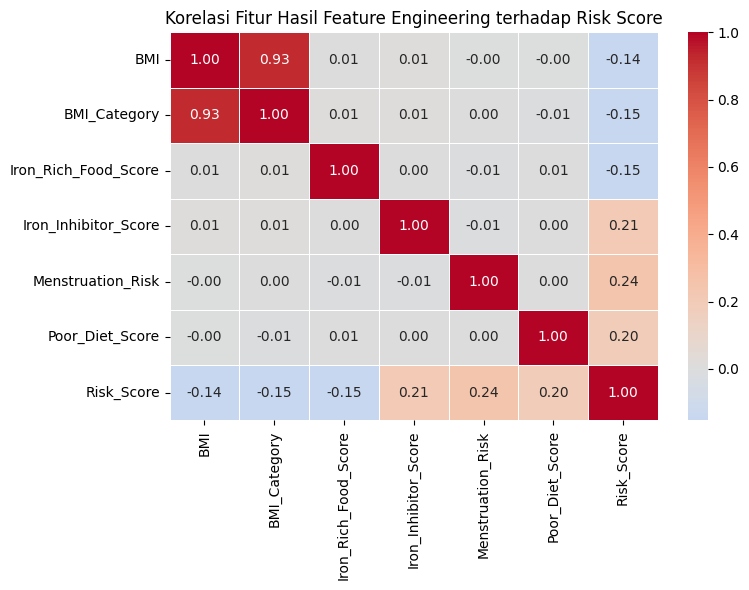

In [ ]:
corr_cols = new_features + ['Risk_Score']
corr_matrix = df_fe[corr_cols].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Korelasi Fitur Hasil Feature Engineering terhadap Risk Score')
plt.tight_layout()
plt.show()

**Insight Korelasi Fitur Hasil Feature Engineering:**

Heatmap korelasi menunjukkan hubungan antara keenam fitur hasil
feature engineering terhadap target `Risk_Score`.
Beberapa temuan penting dari hasil korelasi ini:

- `Menstruation_Risk` memiliki korelasi tertinggi terhadap
  `Risk_Score` (0.35), mengonfirmasi bahwa kondisi menstruasi
  merupakan faktor risiko anemia yang paling dominan pada dataset
  ini — sejalan dengan literatur medis bahwa kehilangan darah
  akibat menstruasi adalah penyebab utama anemia pada wanita
  usia produktif.
- `Iron_Inhibitor_Score` menunjukkan korelasi positif sebesar 0.21
  terhadap `Risk_Score`, artinya semakin sering mengonsumsi teh/kopi
  setelah makan, semakin tinggi risiko anemia.
- `Poor_Diet_Score` memiliki korelasi positif 0.20 terhadap
  `Risk_Score`, menunjukkan bahwa pola makan yang buruk secara
  agregat berkontribusi terhadap peningkatan risiko anemia.
- `Symptom_Score` berkorelasi positif 0.16 terhadap `Risk_Score`,
  yang logis karena semakin banyak gejala yang dirasakan mencerminkan
  tingkat risiko yang lebih tinggi.
- `BMI` dan `Iron_Rich_Food_Score` sama-sama menunjukkan korelasi
  negatif (-0.15) terhadap `Risk_Score` — semakin tinggi BMI dan
  semakin baik asupan makanan kaya zat besi, semakin rendah risiko
  anemia. Temuan ini sejalan dengan referensi jurnal yang menyatakan
  bahwa wanita underweight lebih berisiko dan wanita dengan asupan
  zat besi cukup lebih terlindungi.
- Korelasi antar keenam fitur baru mendekati 0.00, mengindikasikan
  bahwa seluruh fitur tidak saling redundan dan masing-masing
  membawa informasi yang independen bagi model.

Meskipun nilai korelasi individual tergolong moderat, hal ini
wajar karena risiko anemia bersifat multifaktorial — tidak
didominasi satu dimensi saja, melainkan hasil interaksi dari
status gizi, gejala, pola makan, kebiasaan konsumsi, dan kondisi
menstruasi secara bersamaan. Kombinasi keenam fitur ini diharapkan
dapat memperkuat kemampuan model dalam mengenali pola risiko anemia
secara lebih komprehensif.

In [ ]:
df_fe.to_csv('eye_nemia_feature_engineered.csv', index=False)

print('Dataset final berhasil disimpan!')
print(f'Shape final : {df_fe.shape}')
print(f'Fitur baru  : {new_features}')

Dataset final berhasil disimpan!
Shape final : (17398, 38)
Fitur baru  : ['BMI', 'BMI_Category', 'Iron_Rich_Food_Score', 'Iron_Inhibitor_Score', 'Menstruation_Risk', 'Poor_Diet_Score']


# Train-Test Split


In [ ]:
print(df_fe.columns.tolist())

['Age', 'Height_cm', 'Weight_kg', 'Currently_Pregnant', 'Regular_Menstruation', 'Menstruation_Days', 'Menstrual_Blood_Volume', 'Meal_Frequency_Per_Day', 'Eat_Breakfast', 'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg', 'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts', 'Consume_FruitVitC', 'Tea_After_Meal', 'Coffee_After_Meal', 'Junk_Food_Frequency', 'Water_Intake_Glasses', 'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_Headache', 'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_PaleSkin', 'Symptom_ColdExtremities', 'Symptom_Palpitation', 'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness', 'Risk_Score', 'BMI', 'BMI_Category', 'Iron_Rich_Food_Score', 'Iron_Inhibitor_Score', 'Menstruation_Risk', 'Poor_Diet_Score']


In [ ]:
# Pisah fitur (X) dan target (y)
X = df_fe.drop(columns=['Risk_Score', 'BMI'])
y = df_fe['Risk_Score']

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')

Shape X : (17398, 36)
Shape y : (17398,)


**Insight Pemisahan Fitur dan Target:**

Dataset dipisahkan menjadi dua bagian:
- X (fitur): seluruh kolom input sebanyak 30 kolom yang berisi
  informasi pola makan, kondisi menstruasi, kebiasaan konsumsi,
  dan gejala fisik pengguna.
- y (target): kolom Risk_Score yang merupakan label klasifikasi
  risiko anemia (0=Low, 1=Medium, 2=High).

Pemisahan ini diperlukan agar model dapat mempelajari pola
dari fitur X untuk memprediksi nilai target y.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y            # agar proporsi kelas tetap seimbang
)

print(f'Jumlah data training : {X_train.shape[0]}')
print(f'Jumlah data testing  : {X_test.shape[0]}')

Jumlah data training : 13918
Jumlah data testing  : 3480


**Insight Train-Test Split:**

Dataset dibagi menjadi:
- Data training: 13.918 baris (80%) digunakan model untuk belajar pola.
- Data testing : 3.480 baris (20%) digunakan untuk mengevaluasi
  performa model pada data yang belum pernah dilihat sebelumnya.

Parameter yang digunakan:
- `test_size=0.2` — pembagian 80:20 yang merupakan standar umum
  dalam machine learning.
- `random_state=42` — memastikan hasil pembagian data konsisten
  dan dapat direproduksi.
- `stratify=y` — memastikan proporsi kelas Low/Medium/High tetap
  seimbang di data training maupun testing, sehingga model tidak
  bias terhadap kelas tertentu.

In [ ]:
# Pastikan distribusi Risk_Score tetap seimbang setelah split
print('Distribusi kelas y_train:')
print(y_train.value_counts(normalize=True).round(2) * 100)

print()
print('Distribusi kelas y_test:')
print(y_test.value_counts(normalize=True).round(2) * 100)

Distribusi kelas y_train:
Risk_Score
1    34.0
2    33.0
0    33.0
Name: proportion, dtype: float64

Distribusi kelas y_test:
Risk_Score
1    34.0
2    33.0
0    33.0
Name: proportion, dtype: float64


**Insight Verifikasi Distribusi Kelas:**

Hasil verifikasi menunjukkan distribusi kelas Risk_Score yang
seimbang pada kedua subset data:

- y_train: Medium 34%, Low 33%, High 33%
- y_test : Medium 34%, Low 33%, High 33%

Proporsi yang konsisten antara data training dan testing
membuktikan bahwa parameter stratify bekerja dengan baik.
Distribusi yang seimbang ini penting agar model tidak condong
memprediksi salah satu kelas saja.

In [ ]:
scaler = MinMaxScaler()

# Fit HANYA di training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform di testing data
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('=== Setelah Normalisasi ===')
print(X_train_scaled.describe().round(2))

=== Setelah Normalisasi ===
            Age  Height_cm  Weight_kg  Currently_Pregnant  \
count  13918.00   13918.00   13918.00            13918.00   
mean       0.27       0.50       0.41                0.00   
std        0.23       0.18       0.21                0.01   
min        0.00       0.00       0.00                0.00   
25%        0.12       0.38       0.26                0.00   
50%        0.18       0.50       0.40                0.00   
75%        0.38       0.62       0.55                0.00   
max        1.00       1.00       1.00                1.00   

       Regular_Menstruation  Menstruation_Days  Menstrual_Blood_Volume  \
count              13918.00           13918.00                13918.00   
mean                   0.66               0.44                    0.43   
std                    0.48               0.15                    0.25   
min                    0.00               0.00                    0.00   
25%                    0.00               0.29      

**Insight Normalisasi MinMaxScaler:**

Normalisasi dilakukan menggunakan MinMaxScaler yang mengubah
seluruh nilai fitur ke rentang 0.0 hingga 1.0. Hal ini
diperlukan karena dataset memiliki perbedaan skala yang
signifikan antar kolom, misalnya Height_cm bernilai 140–173
sedangkan Symptom_* hanya bernilai 0–4.

Tanpa dinormalisasi, model bisa salah menginterpretasikan kolom
dengan nilai besar sebagai fitur yang lebih penting, walaupun
perbedaan tersebut hanya disebabkan oleh perbedaan satuan.

Scaler hanya di-fit pada data training (X_train), kemudian
hasilnya digunakan untuk mentransformasi data testing (X_test).
Pendekatan ini dilakukan untuk menghindari data leakage, yaitu kondisi di mana informasi dari data testing "bocor" ke proses training sehingga hasil evaluasi model menjadi tidak jujur dan tidak representatif.

In [ ]:
# Export hasil split
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Simpan scaler
joblib.dump(scaler, 'scaler.pkl')

print('Berhasil disimpan!')
print(f'X_train : {X_train_scaled.shape}')
print(f'X_test  : {X_test_scaled.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

Berhasil disimpan!
X_train : (13918, 36)
X_test  : (3480, 36)
y_train : (13918,)
y_test  : (3480,)


In [ ]:
# Load Data
df = df_clean

# Pisahkan kolom berdasarkan tipe
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
# 1. Fungsi Cramer's V (Kategorikal vs Kategorikal)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Koreksi bias (Bias correction)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Fungsi Correlation Ratio (Kategorikal vs Numerik)
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat)+1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(0,cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.average(cat_measures)
    y_total_avg = np.sum(np.multiply(y_avg_array,n_array))/np.sum(n_array)
    numerator = np.sum(np.multiply(n_array,np.power(np.subtract(y_avg_array,y_total_avg),2)))
    denominator = np.sum(np.power(np.subtract(measurements,y_total_avg),2))
    if numerator == 0:
        eta = 0.0
    else:
        eta = np.sqrt(numerator/denominator)
    return eta

In [ ]:
# Buat DataFrame kosong untuk matriks korelasi
all_cols = df.columns
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols)

print("Menghitung Matriks Korelasi... (Ini mungkin memakan waktu beberapa detik)")

# Drop NA untuk keperluan kalkulasi korelasi murni
df_corr = df.dropna()

for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        col1 = all_cols[i]
        col2 = all_cols[j]

        # Jika kolom yang sama (diagonal matriks)
        if i == j:
            corr_matrix.loc[col1, col2] = 1.0

        # Jika Numerik vs Numerik -> Spearman Rank
        elif col1 in num_cols and col2 in num_cols:
            corr_matrix.loc[col1, col2] = df_corr[col1].corr(df_corr[col2], method='spearman')

        # Jika Kategorikal vs Kategorikal -> Cramer's V
        elif col1 in cat_cols and col2 in cat_cols:
            corr_matrix.loc[col1, col2] = cramers_v(df_corr[col1], df_corr[col2])

        # Jika Kategorikal vs Numerik -> Correlation Ratio (Eta)
        elif col1 in cat_cols and col2 in num_cols:
            corr_matrix.loc[col1, col2] = correlation_ratio(df_corr[col1], df_corr[col2])

        # Jika Numerik vs Kategorikal (Sama dengan di atas)
        elif col1 in num_cols and col2 in cat_cols:
            corr_matrix.loc[col1, col2] = correlation_ratio(df_corr[col2], df_corr[col1])

# Pastikan tipe data float
corr_matrix = corr_matrix.astype(float)

Menghitung Matriks Korelasi... (Ini mungkin memakan waktu beberapa detik)


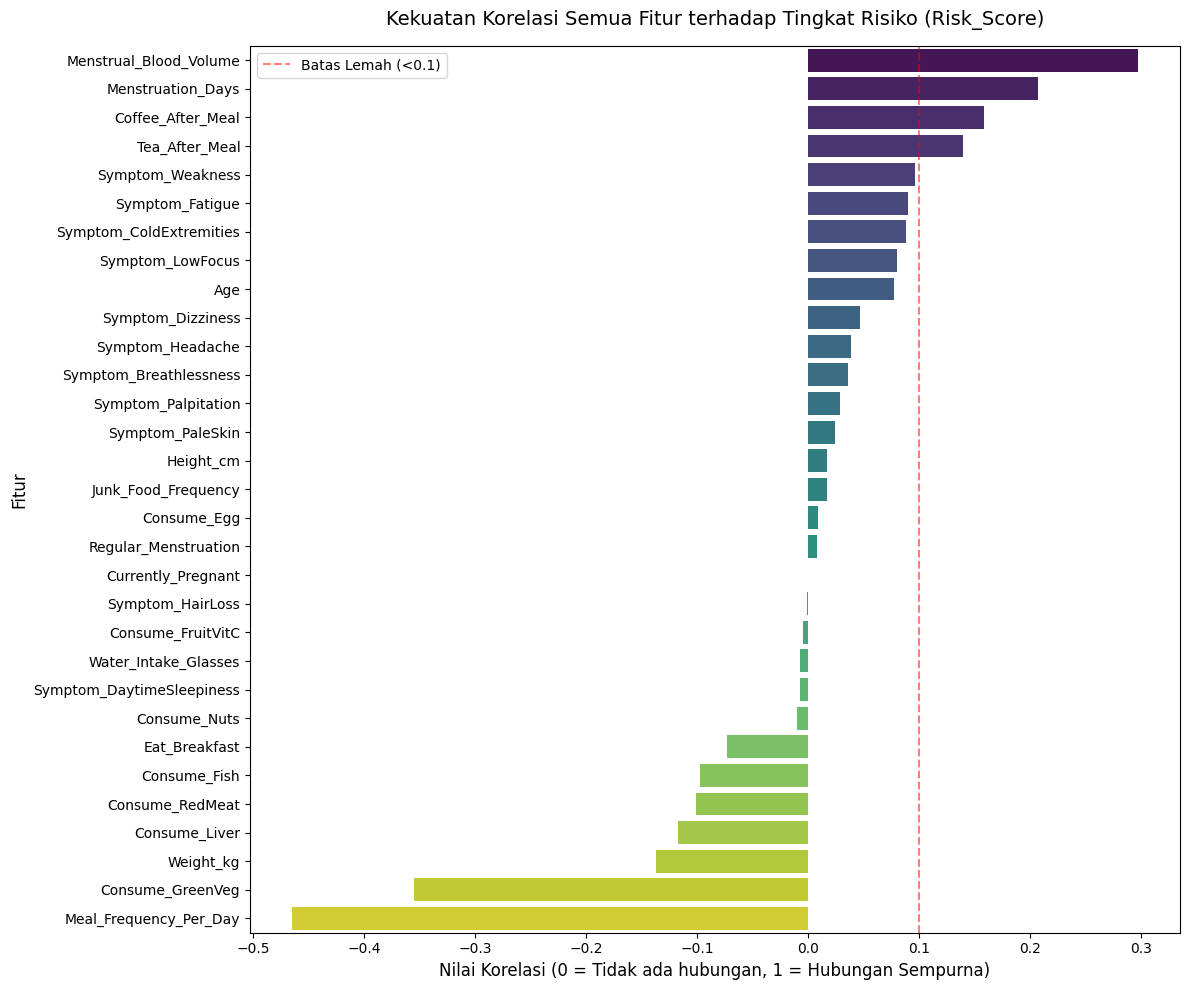

In [ ]:
# Ambil korelasi hanya terhadap kolom 'Risk_Score'
target_corr = corr_matrix[['Risk_Score']].drop('Risk_Score') # Drop agar Risk_Score tidak koreksi dengan dirinya sendiri (1.0)
target_corr = target_corr.sort_values(by='Risk_Score', ascending=False)

# Visualisasi Barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=target_corr['Risk_Score'], y=target_corr.index, palette='viridis')
plt.title('Kekuatan Korelasi Semua Fitur terhadap Tingkat Risiko (Risk_Score)', fontsize=14, pad=15)
plt.xlabel('Nilai Korelasi (0 = Tidak ada hubungan, 1 = Hubungan Sempurna)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Batas Lemah (<0.1)')
plt.legend()
plt.tight_layout()

# Save atau show (gunakan savefig jika berjalan di VM)
# plt.savefig('Korelasi_Risk_Score.png')
plt.show()

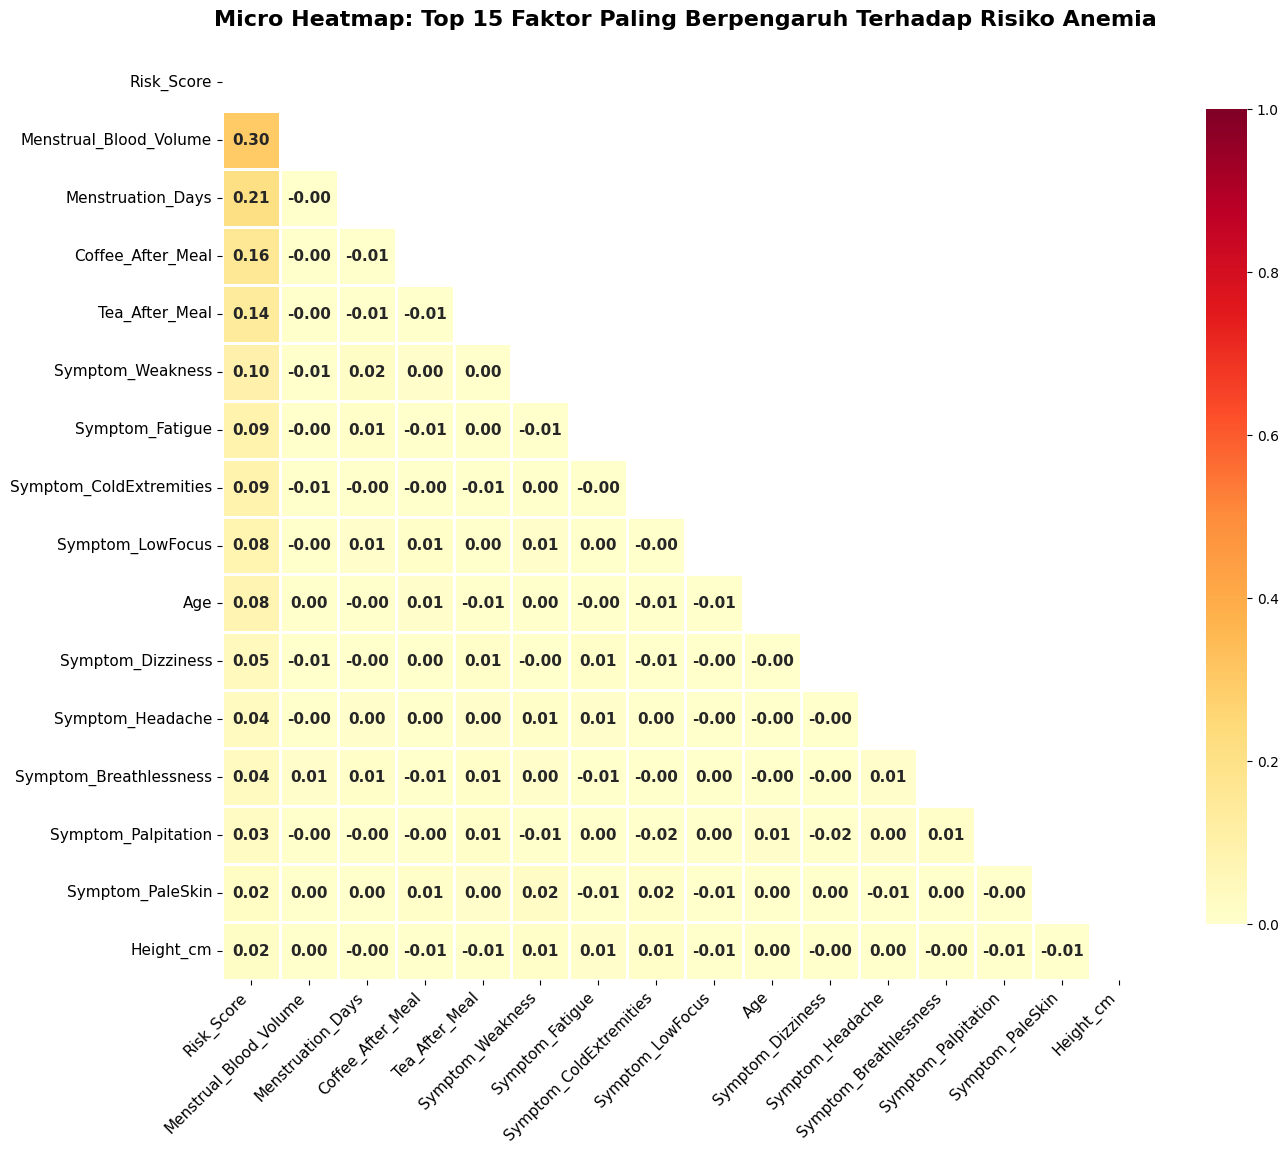

In [ ]:
# 1. Ambil korelasi hanya terhadap 'Risk_Score'
target_corr = corr_matrix[['Risk_Score']].drop('Risk_Score')

# 2. Urutkan dari yang paling kuat ke paling lemah, dan ambil 15 teratas
top_15_features = target_corr.sort_values(by='Risk_Score', ascending=False).head(15).index.tolist()

# 3. Masukkan 'Risk_Score' ke dalam list untuk membuat matriks kecil
top_features_list = ['Risk_Score'] + top_15_features

# 4. Potong matriks korelasi hanya untuk fitur-fitur teratas ini
micro_corr_matrix = corr_matrix.loc[top_features_list, top_features_list]

# 5. Visualisasikan Micro Heatmap
plt.figure(figsize=(14, 12))

# Masking segitiga atas untuk Micro Heatmap
micro_mask = np.triu(np.ones_like(micro_corr_matrix, dtype=bool))

sns.heatmap(micro_corr_matrix,
            mask=micro_mask,
            cmap='YlOrRd',
            vmax=1.0,
            vmin=0.0,
            square=True,
            linewidths=1,
            annot=True,     # Nyalakan angka! (Karena ukurannya sekarang kecil, jadi bisa dibaca)
            fmt=".2f",      # 2 angka di belakang koma
            annot_kws={"size": 11, "weight": "bold"},
            cbar_kws={"shrink": .8})

plt.title('Micro Heatmap: Top 15 Faktor Paling Berpengaruh Terhadap Risiko Anemia', fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

Class Weights: {np.int64(0): np.float64(1.0076744859542426), np.int64(1): np.float64(0.9894078339375845), np.int64(2): np.float64(1.0030990990990991)}
Mapping Kelas: {np.int64(0): np.int64(0), np.int64(1): np.int64(1), np.int64(2): np.int64(2)}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      4,736 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128)       │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64)        │          0 │ dropout_2[0][0],  │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │         99 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 37,379 (146.01 KB)

 Trainable params: 36,611 (143.01 KB)

 Non-trainable params: 768 (3.00 KB)


Memulai proses pelatihan model Deep Learning...
Epoch 1/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5900 - loss: 0.8673 - val_accuracy: 0.6885 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 2/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6717 - loss: 0.6992 - val_accuracy: 0.7023 - val_loss: 0.6317 - learning_rate: 0.0010
Epoch 3/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6798 - loss: 0.6792 - val_accuracy: 0.7046 - val_loss: 0.6318 - learning_rate: 0.0010
Epoch 4/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6893 - loss: 0.6662 - val_accuracy: 0.7101 - val_loss: 0.6167 - learning_rate: 0.0010
Epoch 5/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6895 - loss: 0.6636 - val_accuracy: 0.7170 - val_loss: 0.6112 - learning_rate: 0.0010
Epoch 6/100
435/435 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7028 - loss: 0.6459 - val_accuracy: 0.7253 - val_loss: 0.5920 - learning_rate: 0.0010
Epoch 7/100
435/435 ━━━━━━━━━━━━━

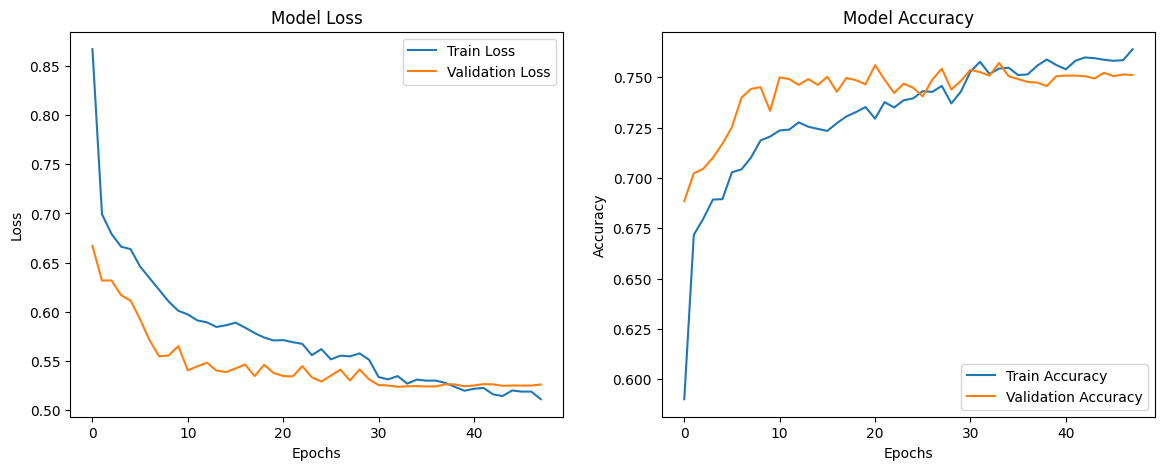

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

CLASSIFICATION REPORT DEEP LEARNING
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      1151
           1       0.62      0.66      0.64      1173
           2       0.84      0.77      0.80      1156

    accuracy                           0.75      3480
   macro avg       0.76      0.75      0.75      3480
weighted avg       0.76      0.75      0.75      3480



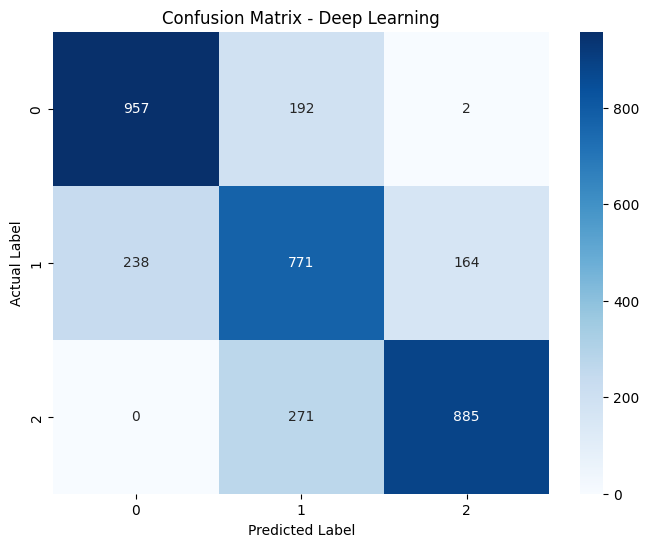

In [ ]:
# ==============================================================================
# TAHAP 1: IMPORT LIBRARY DEEP LEARNING & EVALUASI
# ==============================================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan Anda sudah memiliki X_train_scaled, X_test_scaled, y_train, dan y_test
# dari tahapan splitting dan scalling sebelumnya (MinMaxScaler).

# ==============================================================================
# TAHAP 2: ENCODING VARIABEL TARGET & CLASS WEIGHTS
# ==============================================================================
# Neural Network membutuhkan target berupa angka (0, 1, 2)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Menghitung Class Weights untuk mengatasi Imbalance Data
# Model akan memberikan 'perhatian' lebih pada kelas minoritas (misal: High Risk)
classes = np.unique(y_train_encoded)
weights = class_weight.compute_class_weight(class_weight='balanced',
                                            classes=classes,
                                            y=y_train_encoded)
class_weights_dict = dict(zip(classes, weights))
print("Class Weights:", class_weights_dict)
print("Mapping Kelas:", dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_)))

# ==============================================================================
# TAHAP 3: MEMBANGUN ARSITEKTUR NEURAL NETWORK (DEEP LEARNING)
# ==============================================================================
# Mendapatkan jumlah fitur (input dimensi)
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add
from tensorflow.keras.models import Model

input_dim = X_train_scaled.shape[1]
inputs = Input(shape=(input_dim,))

# Blok Pertama
x = Dense(128, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Blok Residual 1 (Input + Proses -> Output)
res1 = Dense(128, activation='relu')(x)
res1 = BatchNormalization()(res1)
res1 = Dropout(0.2)(res1)
x = Add()([x, res1]) # Menambahkan input awal dari blok ini ke outputnya (Residual Connection)

# Blok Kedua (Pengurangan Dimensi)
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Blok Residual 2
res2 = Dense(64, activation='relu')(x)
res2 = BatchNormalization()(res2)
res2 = Dropout(0.1)(res2)
x = Add()([x, res2])

# Output Layer
x = Dense(32, activation='relu')(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

# ==============================================================================
# TAHAP 4: MENDEFINISIKAN CALLBACKS (EARLY STOPPING & LEARNING RATE)
# ==============================================================================
# Berhenti berlatih jika 'val_loss' tidak membaik selama 15 epoch
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Kurangi Learning Rate jika model mulai stagnan (membantu menemukan titik optimal secara perlahan)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# ==============================================================================
# TAHAP 5: MELATIH MODEL (TRAINING)
# ==============================================================================
print("\nMemulai proses pelatihan model Deep Learning...")
history = model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=100, # Setel tinggi, EarlyStopping akan menghentikannya jika sudah optimal
    batch_size=32,
    validation_data=(X_test_scaled, y_test_encoded),
    class_weight=class_weights_dict, # Terapkan penyeimbang kelas
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ==============================================================================
# TAHAP 6: VISUALISASI PERFORMA TRAINING
# ==============================================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Validation Loss')
ax[0].set_title('Model Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()

# Plot Accuracy
ax[1].plot(history.history['accuracy'], label='Train Accuracy')
ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[1].set_title('Model Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.show()

# ==============================================================================
# TAHAP 7: EVALUASI PADA DATA TEST (CONFUSION MATRIX & REPORT)
# ==============================================================================
# Prediksi probabilitas
y_pred_probs = model.predict(X_test_scaled)

# Mengambil indeks kelas dengan probabilitas tertinggi
y_pred_encoded = np.argmax(y_pred_probs, axis=1)

# Mengembalikan label angka ke bentuk teks (Low, Medium, High) untuk report
y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

print("\n" + "="*50)
print("CLASSIFICATION REPORT DEEP LEARNING")
print("="*50)
print(classification_report(y_test_labels, y_pred_labels))

# Plot Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Deep Learning')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# (Opsional) Simpan Model untuk Deployment di Website
# model.save('anemia_dl_model.h5')
# print("\nModel berhasil disimpan sebagai 'anemia_dl_model.h5'")

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan y_train_encoded dan y_test_encoded sudah berupa angka (0, 1, 2)

# Inisialisasi model XGBoost dengan parameter yang sudah disesuaikan
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    learning_rate=0.05,    # Belajar perlahan
    max_depth=7,           # Kedalaman pohon (bisa menangkap pola kompleks)
    n_estimators=300,      # Jumlah pohon
    subsample=0.8,         # Mencegah overfitting
    colsample_bytree=0.8,  # Mencegah overfitting dari sisi fitur
    random_state=42
)

# Melatih model XGBoost
print("Melatih model XGBoost...")
xgb_model.fit(X_train_scaled, y_train_encoded)

# Prediksi
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Evaluasi
print("\n" + "="*50)
print("CLASSIFICATION REPORT XGBOOST")
print("="*50)
y_pred_labels_xgb = label_encoder.inverse_transform(y_pred_xgb)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)
print(classification_report(y_test_labels, y_pred_labels_xgb))

Melatih model XGBoost...

CLASSIFICATION REPORT XGBOOST
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      1151
           1       0.62      0.66      0.64      1173
           2       0.82      0.78      0.80      1156

    accuracy                           0.74      3480
   macro avg       0.75      0.74      0.75      3480
weighted avg       0.75      0.74      0.75      3480



In [ ]:
# Install imblearn jika belum ada: !pip install imbalanced-learn
from imblearn.under_sampling import TomekLinks
from tensorflow.keras.utils import to_categorical

print("Ukuran X_train sebelum Tomek Links:", X_train_scaled.shape)

# Terapkan Tomek Links HANYA pada data latih (jangan pernah sentuh data test)
tl = TomekLinks()
X_train_clean, y_train_clean = tl.fit_resample(X_train_scaled, y_train_encoded)

print("Ukuran X_train setelah Tomek Links:", X_train_clean.shape)

# Ubah target menjadi One-Hot Encoding (Wajib untuk Label Smoothing)
y_train_onehot = to_categorical(y_train_clean, num_classes=3)
y_test_onehot = to_categorical(y_test_encoded, num_classes=3)

Ukuran X_train sebelum Tomek Links: (13918, 36)
Ukuran X_train setelah Tomek Links: (12626, 36)


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Multiply, Activation
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

input_dim = X_train_clean.shape[1]
inputs = Input(shape=(input_dim,))

# ==========================================
# 1. FEATURE ATTENTION MECHANISM
# ==========================================
# Model belajar memberi bobot/fokus pada fitur tertentu untuk tiap pasien
attention_probs = Dense(input_dim, activation='sigmoid', name='attention_weights')(inputs)
attention_mul = Multiply()([inputs, attention_probs])

# ==========================================
# 2. DEEP REPRESENTATION LEARNING
# ==========================================
x = Dense(128)(attention_mul)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.25)(x)

x = Dense(128)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.2)(x)

x = Dense(64)(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Dropout(0.15)(x)

# ==========================================
# 3. OUTPUT DENGAN LABEL SMOOTHING
# ==========================================
outputs = Dense(3, activation='softmax')(x)

model_attention = Model(inputs=inputs, outputs=outputs)

# Menggunakan Label Smoothing 0.1 (Target tidak mutlak 1, tapi 0.9. Mencegah Overconfidence)
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# Optimizer dengan Learning Rate yang sedikit lebih besar di awal
optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

model_attention.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
model_attention.summary()

# ==========================================
# 4. CALLBACKS & TRAINING
# ==========================================
# Sabar lebih lama (patience=20) karena attention butuh waktu untuk konvergen
early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=6, min_lr=0.00001)

print("\nMemulai pelatihan Tabular Attention Network...")
history = model_attention.fit(
    X_train_clean,
    y_train_onehot,
    epochs=150,
    batch_size=64, # Batch size dibesarkan agar gradient lebih stabil
    validation_data=(X_test_scaled, y_test_onehot),
    # class_weight tidak terlalu diperlukan lagi karena data balance dan disempurnakan TomekLinks
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 36)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 36)        │      1,332 │ input_layer_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 36)        │          0 │ input_layer_1[0]… │
│                     │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      4,736 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 128)       │     16,512 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128)       │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      8,256 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64)        │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 3)         │        195 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,311 (126.21 KB)

 Trainable params: 31,671 (123.71 KB)

 Non-trainable params: 640 (2.50 KB)


Memulai pelatihan Tabular Attention Network...
Epoch 1/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6312 - loss: 0.8690 - val_accuracy: 0.6009 - val_loss: 0.9139 - learning_rate: 0.0020
Epoch 2/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7113 - loss: 0.7467 - val_accuracy: 0.7072 - val_loss: 0.7375 - learning_rate: 0.0020
Epoch 3/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7230 - loss: 0.7260 - val_accuracy: 0.7273 - val_loss: 0.7119 - learning_rate: 0.0020
Epoch 4/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7358 - loss: 0.7096 - val_accuracy: 0.7388 - val_loss: 0.6927 - learning_rate: 0.0020
Epoch 5/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7406 - loss: 0.7000 - val_accuracy: 0.7394 - val_loss: 0.6892 - learning_rate: 0.0020
Epoch 6/150
198/198 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7414 - loss: 0.6944 - val_accuracy: 0.7359 - val_loss: 0.6847 - learning_rate: 0.0020
Epoch 7/150
198/198 ━━━━━━━━━━━━━━

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Prediksi menggunakan data test yang ASLI (tanpa Tomek Links)
y_pred_probs = model_attention.predict(X_test_scaled)
y_pred_encoded = np.argmax(y_pred_probs, axis=1)

y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)
y_test_labels = label_encoder.inverse_transform(y_test_encoded)

print("\n" + "="*50)
print("CLASSIFICATION REPORT - ATTENTION NETWORK")
print("="*50)
print(classification_report(y_test_labels, y_pred_labels))

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

CLASSIFICATION REPORT - ATTENTION NETWORK
              precision    recall  f1-score   support

           0       0.80      0.85      0.82      1151
           1       0.64      0.63      0.63      1173
           2       0.83      0.78      0.80      1156

    accuracy                           0.75      3480
   macro avg       0.75      0.75      0.75      3480
weighted avg       0.75      0.75      0.75      3480

